In [5]:
import torch
import torch.nn as nn
import math
import logging

# Set default tensor type
torch.set_default_dtype(torch.float64)


def rbf_kernel(X1, X2, lengthscale=1.0, variance=1.0):
    """
    Computes the RBF kernel matrix between two sets of points.
    """
    lengthscale = torch.as_tensor(lengthscale, dtype=X1.dtype, device=X1.device)
    variance = torch.as_tensor(variance, dtype=X1.dtype, device=X1.device)
    sqdist = torch.cdist(X1, X2, p=2).pow(2)
    return variance * torch.exp(-0.5 * sqdist / lengthscale**2)


class TPRTFullBatch_Tang:
    """
    Implementation of the full (non-sparse) Student-t Process regression model
    using the Laplace Approximation.
    This version uses a custom Conjugate Gradient optimizer for the M-step,
    to align with the original paper.
    """
    def __init__(self, X, y, nu_f=2.1, nu_e=2.1,
                 kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_sigma=1.0):
        
        self.X = X
        self.y = y.view(-1, 1)
        self.N, self.D = X.shape

        # Hyperparameters are now stored in a list for easier handling in the optimizer
        self.params_to_optimize = [
            nn.Parameter(torch.log(torch.tensor(kernel_lengthscale))),
            nn.Parameter(torch.log(torch.tensor(kernel_variance))),
            nn.Parameter(torch.log(torch.tensor(likelihood_sigma))),
            nn.Parameter(torch.log(torch.tensor(nu_f))),
            nn.Parameter(torch.log(torch.tensor(nu_e)))
        ]
        (self.log_kernel_lengthscale, self.log_kernel_variance, self.log_likelihood_sigma,
         self.log_nu_f, self.log_nu_e) = self.params_to_optimize

        self.m_f = torch.zeros(self.N, 1, dtype=X.dtype, device=X.device)

    def _get_hyperparams(self):
        # (変更なし)
        return {
            "lengthscale": torch.exp(self.log_kernel_lengthscale),
            "variance": torch.exp(self.log_kernel_variance),
            "sigma": torch.exp(self.log_likelihood_sigma),
            "nu_f": torch.exp(self.log_nu_f),
            "nu_e": torch.exp(self.log_nu_e)
        }
        
    def _find_f_hat(self, K_inv, params, max_iter=10, tol=1e-5):
        # (論文に合わせてこちらもCGにすべきだが、まずはLBFGSで様子を見る)
        f = nn.Parameter(self.m_f.clone())
        optimizer = torch.optim.LBFGS([f], lr=0.5, max_iter=20, line_search_fn="strong_wolfe")
        def closure():
            optimizer.zero_grad()
            log_lik_term = ((params['nu_e'] + 1) / 2) * torch.log(1 + (1 / params['nu_e']) * ((self.y - f) / params['sigma']).pow(2))
            fT_K_inv_f = f.T @ K_inv @ f
            log_prior_term = ((params['nu_f'] + self.N) / 2) * torch.log(1 + (1 / params['nu_f']) * fT_K_inv_f)
            loss = torch.sum(log_lik_term) + log_prior_term
            loss.backward()
            return loss
        for _ in range(max_iter):
            optimizer.step(closure)
        return f.detach()

    def _e_step(self, mode_finding_iter=10):
        # (変更なし、安定性のためのtry-exceptを追加)
        with torch.no_grad():
            params = self._get_hyperparams()
            K = rbf_kernel(self.X, self.X, params['lengthscale'], params['variance'])
            K += torch.eye(self.N, device=self.X.device) * 1e-6
            try:
                L = torch.linalg.cholesky(K)
                K_inv = torch.cholesky_inverse(L)
            except torch.linalg.LinAlgError:
                logging.warning("E-step: Cholesky decomposition failed. Skipping mode finding.")
                return
            self.m_f.copy_(self._find_f_hat(K_inv, params, max_iter=mode_finding_iter))

    def _calculate_neg_log_marginal_likelihood(self):
        # (変更なし、安定性のためのtry-exceptとclampを追加)
        params = self._get_hyperparams()
        f_hat = self.m_f
        try:
            K = rbf_kernel(self.X, self.X, params['lengthscale'], params['variance'])
            K += torch.eye(self.N, device=self.X.device) * 1e-6
            L = torch.linalg.cholesky(K)
            K_inv = torch.cholesky_inverse(L)
        except torch.linalg.LinAlgError:
            logging.warning("M-step loss: Cholesky decomposition failed on K.")
            return torch.tensor(float('inf'), device=self.X.device)

        fT_K_inv_f = f_hat.T @ K_inv @ f_hat
        log_lik_inner = 1 + (1 / params['nu_e']) * ((self.y - f_hat) / params['sigma']).pow(2)
        log_prior_inner = 1 + (1 / params['nu_f']) * fT_K_inv_f
        log_lik_term = ((params['nu_e'] + 1) / 2) * torch.log(log_lik_inner.clamp(min=1e-9))
        log_prior_term = ((params['nu_f'] + self.N) / 2) * torch.log(log_prior_inner.clamp(min=1e-9))
        ln_Q_at_f_hat = torch.sum(log_lik_term) + log_prior_term

        f_hat_flat = f_hat.squeeze()
        prior_hess_num = K_inv * (params['nu_f'] + fT_K_inv_f) - 2 * (K_inv @ torch.outer(f_hat_flat, f_hat_flat) @ K_inv)
        prior_hess_den = (params['nu_f'] + fT_K_inv_f)**2
        prior_hess = (params['nu_f'] + self.N) * (prior_hess_num / prior_hess_den)

        err_sq = (self.y - f_hat).pow(2)
        nu_e_sigma_sq = params['nu_e'] * params['sigma']**2
        lik_hess_num = err_sq - nu_e_sigma_sq
        lik_hess_den = (err_sq + nu_e_sigma_sq)**2
        W_diag = -(params['nu_e'] + 1) * (lik_hess_num / lik_hess_den)
        W = torch.diag(W_diag.squeeze())
        A = prior_hess + W

        log_det_K = 2 * torch.sum(torch.log(torch.diag(L)))
        sign, log_det_A = torch.linalg.slogdet(A)
        if sign.item() <= 0:
            logging.warning("M-step loss: Hessian (A) is not positive definite.")
            return torch.tensor(float('inf'), device=self.X.device)
        
        log_term = -0.5 * log_det_K + 0.5 * log_det_A
        
        c_nu_f_term = torch.lgamma((params['nu_f'] + self.N)/2) - torch.lgamma(params['nu_f']/2) - (self.N/2)*torch.log(math.pi * params['nu_f'])
        c_nu_e_term = self.N * (torch.lgamma((params['nu_e'] + 1)/2) - torch.lgamma(params['nu_e']/2) - 0.5*torch.log(math.pi * params['nu_e']))
        c_sigma_term = -self.N * torch.log(params['sigma'])

        return ln_Q_at_f_hat - log_term - (c_nu_f_term + c_nu_e_term + c_sigma_term)

    # === M-STEP & FIT METHOD RE-IMPLEMENTATION WITH CONJUGATE GRADIENT ===

    def _get_flat_params_and_grads(self):
        """Helper to get flattened parameters and their gradients."""
        views = []
        for p in self.params_to_optimize:
            if p.grad is None:
                # 勾配が計算されていない場合はゼロベクトルで初期化
                view = p.new(p.numel()).zero_()
            else:
                view = p.grad.view(-1)
            views.append(view)
        return torch.cat(views, 0)

    def _set_flat_params(self, flat_params):
        """Helper to set parameters from a flattened vector."""
        offset = 0
        for p in self.params_to_optimize:
            numel = p.numel()
            p.data.copy_(flat_params[offset:offset + numel].view_as(p))
            offset += numel

    def _line_search(self, f, x, d, g, loss_init, lr_init=1.0, alpha=0.1, beta=0.7):
        """Backtracking line search to find a suitable step size."""
        lr = lr_init
        while True:
            x_new = x + lr * d
            loss_new = f(x_new).item()
            # Armijo-Goldstein condition
            if loss_new <= loss_init + alpha * lr * torch.dot(g, d):
                return lr
            lr *= beta
            if lr < 1e-10: # ステップサイズが小さすぎる場合は探索を打ち切る
                return lr
    
    def fit(self, max_iter_global=100, mode_finding_iter=10, cg_restarts=10):
        """
        Fits the model using an EM-like algorithm.
        The M-step uses a manually implemented Conjugate Gradient method.
        """
        loss_history = []
        
        # --- Conjugate Gradient (Fletcher-Reeves) M-step ---
        # 損失関数を定義（引数はフラットなパラメータベクトル）
        def loss_fn(flat_params):
            self._set_flat_params(flat_params)
            return self._calculate_neg_log_marginal_likelihood()
        
        for i in range(max_iter_global):
            # E-Step: Find the posterior mode f_hat
            self._e_step(mode_finding_iter=mode_finding_iter)

            # --- M-Step with CG starts here ---
            # 1. 現在のパラメータと損失を計算
            current_params_flat = torch.cat([p.data.view(-1) for p in self.params_to_optimize])
            
            # 2. 勾配を計算
            loss = loss_fn(current_params_flat)
            if torch.isinf(loss) or torch.isnan(loss):
                logging.warning(f"M-step {i+1}: Initial loss is inf/nan. Skipping update.")
                loss_history.append(loss.item())
                continue
            
            # パラメータの勾配をクリア
            for p in self.params_to_optimize:
                if p.grad is not None:
                    p.grad.detach_()
                    p.grad.zero_()
            
            loss.backward()
            g = self._get_flat_params_and_grads() # g_k: 現在の勾配
            
            # 3. CGの初期化
            d = -g  # d_0 = -g_0: 最初の探索方向
            g_norm_sq_old = torch.dot(g, g) # ||g_k||^2
            
            # CGの内部ループ (論文ではCGの反復回数に言及がないため、適当な回数設定)
            # EMの1イテレーション内でCGを数回実行する
            for j in range(cg_restarts): 
                if torch.norm(g) < 1e-5: # 勾配が小さければ収束とみなす
                    break

                # 4. 直線探索でステップサイズ(lr)を決定
                lr = self._line_search(loss_fn, current_params_flat, d, g, loss.item())

                # 5. パラメータを更新: x_{k+1} = x_k + lr * d_k
                current_params_flat += lr * d
                self._set_flat_params(current_params_flat)

                # 6. 新しい勾配を計算: g_{k+1}
                loss = loss_fn(current_params_flat)
                if torch.isinf(loss) or torch.isnan(loss):
                     logging.warning(f"M-step {i+1}, CG iter {j+1}: Loss became inf/nan. Stopping CG.")
                     # 1つ前の状態に戻す
                     current_params_flat -= lr * d
                     self._set_flat_params(current_params_flat)
                     break
                
                loss.backward()
                g = self._get_flat_params_and_grads()

                # 7. βを計算 (Fletcher-Reeves): β_k = ||g_{k+1}||^2 / ||g_k||^2
                g_norm_sq_new = torch.dot(g, g)
                beta = g_norm_sq_new / g_norm_sq_old
                g_norm_sq_old = g_norm_sq_new

                # 8. 新しい探索方向を計算: d_{k+1} = -g_{k+1} + β_k * d_k
                d = -g + beta * d
            
            loss_history.append(loss.item())

        return loss_history
        
    def predict(self, X_test):
        # (変更なし)
        with torch.no_grad():
            params = self._get_hyperparams()
            f_hat = self.m_f

            try:
                K = rbf_kernel(self.X, self.X, params['lengthscale'], params['variance'])
                K += torch.eye(self.N, device=self.X.device) * 1e-6
                L = torch.linalg.cholesky(K)
                K_inv = torch.cholesky_inverse(L)
            except torch.linalg.LinAlgError:
                logging.error("Prediction failed: Cholesky decomposition failed on K.")
                pred_mean = torch.zeros(X_test.shape[0], 1, device=self.X.device)
                pred_var = torch.full((X_test.shape[0], 1), 1e6, device=self.X.device)
                pred_nu = torch.tensor(float('inf'), device=self.X.device)
                return pred_mean, pred_var, pred_nu
            
            K_star_x = rbf_kernel(X_test, self.X, params['lengthscale'], params['variance'])
            K_star_star_diag = rbf_kernel(X_test, X_test, params['lengthscale'], params['variance']).diag()

            pred_mean = K_star_x @ K_inv @ f_hat

            f_hat_flat = f_hat.squeeze()
            fT_K_inv_f = f_hat.T @ K_inv @ f_hat
            prior_hess_num = K_inv * (params['nu_f'] + fT_K_inv_f) - 2 * (K_inv @ torch.outer(f_hat_flat, f_hat_flat) @ K_inv)
            prior_hess_den = (params['nu_f'] + fT_K_inv_f)**2
            prior_hess = (params['nu_f'] + self.N) * (prior_hess_num / prior_hess_den)
            
            err_sq = (self.y - f_hat).pow(2)
            nu_e_sigma_sq = params['nu_e'] * params['sigma']**2
            lik_hess_num = err_sq - nu_e_sigma_sq
            lik_hess_den = (err_sq + nu_e_sigma_sq)**2
            W_diag = -(params['nu_e'] + 1) * (lik_hess_num / lik_hess_den)
            W = torch.diag(W_diag.squeeze())
            A = prior_hess + W
            
            try:
                L_A = torch.linalg.cholesky(A)
                A_inv = torch.cholesky_inverse(L_A)
            except torch.linalg.LinAlgError:
                logging.warning("Prediction: Hessian not positive definite. Using pseudo-inverse.")
                A_inv = torch.linalg.pinv(A)

            K_inv_k_star = torch.cholesky_solve(K_star_x.T, L)
            prior_var_reduction = (K_star_x * K_inv_k_star.T).sum(dim=1)
            posterior_uncertainty = (K_star_x @ K_inv @ A_inv @ K_inv @ K_star_x.T).diag()
            
            pred_var = K_star_star_diag - prior_var_reduction + posterior_uncertainty
            pred_var = pred_var.clamp(min=1e-9)
            
            pred_nu = torch.tensor(float('inf'), device=self.X.device)
            
            return pred_mean, pred_var.unsqueeze(1), pred_nu

In [4]:
import matplotlib.pyplot as plt

if __name__ == '__main__':
    # 1. Generate synthetic data with outliers
    N = 60
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    y_true = torch.sin(X_train) * 2
    
    torch.manual_seed(42)
    noise = torch.randn(N, 1) * 0.5
    y_train = y_true + noise
    
    outlier_indices = [5, 15, 30, 45, 55]
    y_train[outlier_indices] = torch.tensor([-3.0, 4.0, -4.5, 5.0, -2.5]).unsqueeze(1)

    # 2. Setup the model
    model = TPRTFullBatch_Tang(
        X=X_train,
        y=y_train,
        nu_f=2.1,
        nu_e=2.1,
        kernel_lengthscale=1.0,
        kernel_variance=1.0,
        likelihood_sigma=0.5
    )

    # 3. Fit the model
    loss_history = model.fit(max_iter_global=100, mode_finding_iter=10)

    # 4. Make predictions
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean, pred_var, pred_nu = model.predict(X_test)

    # 5. Visualize the results
    plt.figure(figsize=(12, 8))
    
    pred_std = torch.sqrt(pred_var)
    # Since nu is inf, the predictive distribution is Gaussian
    # We use norm.ppf for confidence intervals (equivalent to multiplying by ~1.96)
    lower_quantile = norm.ppf(0.025)
    upper_quantile = norm.ppf(0.975)
    
    lower_ci = pred_mean + lower_quantile * pred_std
    upper_ci = pred_mean + upper_quantile * pred_std

    plt.fill_between(X_test.squeeze(), lower_ci.squeeze(), upper_ci.squeeze(), color='orange', alpha=0.3, label='95% Predictive Interval (Gaussian Approx.)')
    plt.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=2, label='Training Data (with outliers)')
    plt.plot(X_test, torch.sin(X_test) * 2, 'b--', label='True Function')

    plt.title('TPRT with Laplace Approximation (Standardized Format)', fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    
    # Print final learned hyperparameters
    params = model._get_hyperparams()
    print("\n--- Learned Hyperparameters ---")
    print(f"Kernel Lengthscale: {params['lengthscale'].item():.3f}")
    print(f"Kernel Variance: {params['variance'].item():.3f}")
    print(f"Likelihood Sigma: {params['sigma'].item():.3f}")
    print(f"Prior DoF (nu_f): {params['nu_f'].item():.3f}")
    print(f"Likelihood DoF (nu_e): {params['nu_e'].item():.3f}")

    # Plot loss curve
    plt.figure(figsize=(12, 6))
    plt.plot(loss_history)
    plt.title("Approx. Negative Log Marginal Likelihood Convergence")
    plt.xlabel("EM-like Iteration")
    plt.ylabel("Loss")
    plt.grid(True)
    
    plt.show()

KeyboardInterrupt: 

Optimizing hyperparameters...


/tmp/ipykernel_406576/4261276541.py:73: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  result = minimize(


KeyboardInterrupt: 

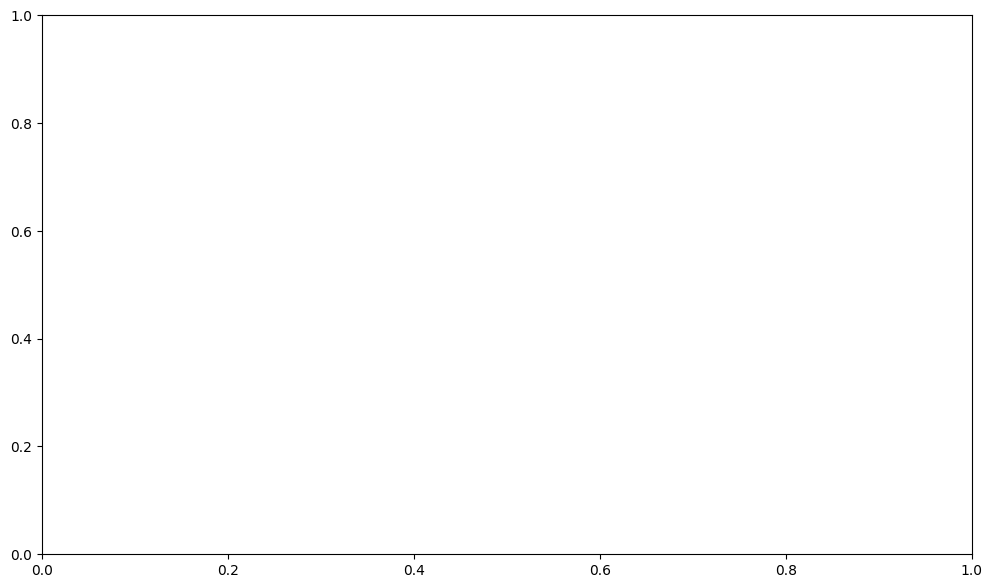

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.special import loggamma
from scipy.linalg import cholesky, cho_solve, solve_triangular

# For reproducibility
np.random.seed(42)

# Turn on Matplotlib's interactive mode for live plotting
plt.ion()

class TPRT:
    """
    Student-t Process Regression with Student-t Likelihood (TPRT).
    
    This implementation uses Laplace approximation for inference and optimizes
    hyperparameters by minimizing the negative log marginal likelihood.
    
    The fit method includes a `live_plot` option to visualize optimization.
    """
    def __init__(self):
        # Final model parameters (optimized)
        self.log_hyperparams = None
        self.X_train = None
        self.y_train = None
        self.f_hat = None
        self.A = None
        self.K = None
        self.K_inv = None
        
        # --- Attributes for live plotting callback ---
        self.temp_f_hat = None
        self.temp_A = None
        self.temp_K = None
        self.temp_K_inv = None
        self.iter_count = 0
        self.fig, self.ax = None, None

    def _kernel(self, X1, X2, length_scale):
        """Squared Exponential (RBF) kernel."""
        sqdist = np.sum(X1**2, 1).reshape(-1, 1) + np.sum(X2**2, 1) - 2 * np.dot(X1, X2.T)
        # Add a small epsilon to avoid division by zero if length_scale is tiny
        return np.exp(-0.5 * sqdist / (length_scale**2 + 1e-9))

    def fit(self, X, y, initial_hyperparams=None, live_plot=False):
        """
        Train the TPRT model.
        
        This involves finding the optimal hyperparameters by minimizing the
        negative log marginal likelihood (NLML).

        Args:
            X (np.ndarray): Training inputs.
            y (np.ndarray): Training targets.
            initial_hyperparams (np.ndarray, optional): Starting point for optimization.
            live_plot (bool, optional): If True, shows a live plot of the fit during optimization.
        """
        self.X_train = X
        self.y_train = y
        self.iter_count = 0 # Reset counter for each fit

        if initial_hyperparams is None:
            # log(v1), log(v2), log(sigma_n), log(length_scale)
            initial_hyperparams = np.array([np.log(30), np.log(30), np.log(0.1), np.log(1.0)])

        # Set up the callback function if live plotting is enabled
        callback_fn = self._live_plot_callback if live_plot else None
        if live_plot:
            self.fig, self.ax = plt.subplots(figsize=(12, 7))

        print("Optimizing hyperparameters...")
        result = minimize(
            fun=self._nlml_objective,
            x0=initial_hyperparams,
            method='L-BFGS-B',
            options={'disp': True, 'maxiter': 100},
            callback=callback_fn
        )

        # Handle the plot window after optimization
        if live_plot:
            plt.ioff() # Turn off interactive mode
            print("Live plotting finished. Displaying final result.")
            plt.show() # Keep the final plot window open

        self.log_hyperparams = result.x
        print(f"Optimal log hyperparameters: {self.log_hyperparams}")

        # After finding the best hyperparameters, store the final model state
        self._nlml_objective(self.log_hyperparams, store_results=True)
        print("Training complete.")

    def _nlml_objective(self, log_hyperparams, store_results=False):
        """Objective function: Negative Log Marginal Likelihood."""
        n = self.X_train.shape[0]
        
        # 1. Unpack hyperparameters
        v1 = np.exp(log_hyperparams[0])
        v2 = np.exp(log_hyperparams[1])
        sigma_n = np.exp(log_hyperparams[2])
        length_scale = np.exp(log_hyperparams[3])

        # 2. Compute kernel matrix and its inverse
        K = self._kernel(self.X_train, self.X_train, length_scale)
        K += 1e-6 * np.eye(n) # Jitter
        try:
            L = cholesky(K, lower=True)
            K_inv = cho_solve((L, True), np.eye(n))
        except np.linalg.LinAlgError:
            return np.inf

        # 3. Find the posterior mode f_hat (Inner Loop)
        def neg_log_posterior(f):
            fT_K_inv_f = f.T @ K_inv @ f
            log_prior = -((v1 + n) / 2.0) * np.log(1 + fT_K_inv_f / v1)
            scaled_error_sq = ((self.y_train - f) / sigma_n)**2
            log_likelihood = np.sum(-((v2 + 1) / 2.0) * np.log(1 + scaled_error_sq / v2))
            return -(log_prior + log_likelihood)

        def grad_neg_log_posterior(f):
            fT_K_inv_f = f.T @ K_inv @ f
            grad_log_prior = -((v1 + n) / (v1 + fT_K_inv_f)) * (K_inv @ f)
            scaled_error = (self.y_train - f) / sigma_n
            grad_log_likelihood = ((v2 + 1) / (v2 + scaled_error**2)) * (scaled_error / sigma_n)
            return -(grad_log_prior + grad_log_likelihood)

        res = minimize(fun=neg_log_posterior, x0=np.zeros(n), method='L-BFGS-B', jac=grad_neg_log_posterior)
        f_hat = res.x

        # 4. Compute Hessian of negative log posterior at f_hat
        fT_K_inv_f = f_hat.T @ K_inv @ f_hat
        c1 = (v1 + n) / (v1 + fT_K_inv_f)
        c2 = -2 * (v1 + n) / (v1 + fT_K_inv_f)**2
        K_inv_f = K_inv @ f_hat
        H_prior = c1 * K_inv + c2 * np.outer(K_inv_f, K_inv_f)
        
        scaled_error_sq = ((self.y_train - f_hat) / sigma_n)**2
        numerator = (v2 + 1) * (1 - scaled_error_sq / v2)
        denominator = sigma_n**2 * (1 + scaled_error_sq / v2)**2
        W_diag = numerator / denominator
        H_likelihood = np.diag(W_diag)
        
        H = H_prior + H_likelihood

        # 5. Compute the Negative Log Marginal Likelihood
        try:
            sign, logdet_H = np.linalg.slogdet(H)
            if sign != 1: return np.inf
        except np.linalg.LinAlgError:
            return np.inf

        nlml = neg_log_posterior(f_hat) + 0.5 * logdet_H - 0.5 * n * np.log(2 * np.pi)

        # Store temporary state for the live plot callback
        self.temp_f_hat = f_hat
        try:
            self.temp_A = np.linalg.inv(H)
        except np.linalg.LinAlgError: # If Hessian is singular, callback can't work
            self.temp_A = np.eye(n) * 1e-6
        self.temp_K = K
        self.temp_K_inv = K_inv
        
        if store_results:
            self.f_hat = self.temp_f_hat
            self.A = self.temp_A
            self.K = self.temp_K
            self.K_inv = self.temp_K_inv
            
        return nlml

    def _live_plot_callback(self, current_hyperparams):
        """Callback to update a plot live during optimization."""
        self.iter_count += 1
        
        self.ax.clear()
        
        length_scale = np.exp(current_hyperparams[3])
        X_test = np.linspace(self.X_train.min() - 0.2, self.X_train.max() + 0.2, 200).reshape(-1, 1)
        
        k_star = self._kernel(self.X_train, X_test, length_scale)
        k_star_star = self._kernel(X_test, X_test, length_scale)
        
        pred_mean = k_star.T @ self.temp_K_inv @ self.temp_f_hat
        
        v = self.temp_K_inv @ k_star
        pred_var = np.diag(k_star_star) - np.diag(k_star.T @ v)
        pred_var += np.diag(v.T @ self.temp_A @ v)
        std_pred = np.sqrt(np.maximum(pred_var, 0)) # Ensure non-negative variance

        self.ax.plot(self.X_train, self.y_train, 'kx', markersize=8, label='Training Data')
        self.ax.plot(X_test, pred_mean, 'b-', label='Current Prediction')
        self.ax.fill_between(X_test.ravel(), pred_mean - 1.96 * std_pred, pred_mean + 1.96 * std_pred,
                             color='blue', alpha=0.2)
        v1, v2, sigma_n, l = np.exp(current_hyperparams)
        self.ax.set_title(f'Iteration: {self.iter_count} | v1={v1:.2f}, v2={v2:.2f}, σ={sigma_n:.3f}, l={l:.3f}')
        self.ax.set_ylim(-2, 2.5)
        self.ax.grid(True)
        self.ax.legend(loc='upper left')
        
        self.fig.canvas.draw()
        plt.pause(0.1)

    def predict(self, X_star):
        """Make predictions for new data X_star."""
        if self.f_hat is None:
            raise RuntimeError("Model has not been trained. Call fit() first.")
            
        length_scale = np.exp(self.log_hyperparams[3])
        
        k_star = self._kernel(self.X_train, X_star, length_scale)
        k_star_star = self._kernel(X_star, X_star, length_scale)

        pred_mean = k_star.T @ self.K_inv @ self.f_hat

        v = self.K_inv @ k_star
        pred_var = np.diag(k_star_star) - np.diag(k_star.T @ v)
        pred_var += np.diag(v.T @ self.A @ v)
        std_pred = np.sqrt(np.maximum(pred_var, 0))

        return pred_mean, std_pred

# --- Main execution block ---
if __name__ == '__main__':
    # 1. Generate synthetic data with outliers
    def true_function(x):
        return np.sin(x * 3 * np.pi) / (x * 3 * np.pi) if x != 0 else 1.0
    
    X_train_base = np.linspace(-1, 1, 100).reshape(-1, 1)
    y_true = np.array([true_function(x) for x in X_train_base.ravel()])
    y_train = y_true + np.random.normal(0, 0.05, size=y_true.shape)

    # Add target outliers
    y_train[20] += 1.0
    y_train[80] -= 0.8
    # Add input outliers
    X_outlier = np.array([[-0.8], [0.9]])
    y_outlier = np.array([1.5, -1.2])
    X_train = np.vstack([X_train_base, X_outlier])
    y_train = np.hstack([y_train, y_outlier])

    # 2. Fit the TPRT model with live plotting
    tprt = TPRT()
    tprt.fit(X_train, y_train, live_plot=True)

    # 3. Make final predictions and plot
    X_test = np.linspace(-1.2, 1.2, 200).reshape(-1, 1)
    y_pred, std_pred = tprt.predict(X_test)

    plt.figure(figsize=(12, 7))
    y_test_true = np.array([true_function(x) for x in X_test.ravel()])
    plt.plot(X_test, y_test_true, 'g--', label='True Function')
    plt.plot(X_train, y_train, 'kx', markersize=8, label='Training Data (with outliers)')
    plt.plot(X_test, y_pred, 'b-', label='Final TPRT Prediction')
    plt.fill_between(X_test.ravel(), y_pred - 1.96 * std_pred, y_pred + 1.96 * std_pred,
                     color='blue', alpha=0.2, label='95% Confidence Interval')
    
    v1_opt, v2_opt, _, _ = np.exp(tprt.log_hyperparams)
    plt.title(f'Final TPRT Regression (v1={v1_opt:.2f}, v2={v2_opt:.2f})')
    plt.xlabel('X')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True)
    plt.ylim(-2, 2.5)
    plt.show()

In [9]:
import numpy as np
from scipy.special import gamma, digamma # For Gamma function and its derivative (digamma)
from scipy.optimize import minimize # For conjugate gradient optimization
import logging

# Configure logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

class TPRT:
    """
    Student-t Process Regression with Student-t Likelihood (TPRT)
    
    This class implements the TPRT model as described in the paper
    "Student-t Process Regression with Student-t Likelihood" by Tang et al. (2017).
    It handles both input and target outliers by using a Student-t Process prior
    and a Student-t likelihood. Inference is performed using Laplace approximation.
    """
    
    def __init__(self, kernel_func=None, initial_hyperparameters=None):
        """
        Initializes the TPRT model.
        
        Args:
            kernel_func (callable, optional): The kernel function to use.
                It should take (X1, X2, length_scale, signal_variance) as arguments.
                Defaults to squared_exponential_kernel.
            initial_hyperparameters (np.ndarray, optional): Initial guess for
                log-transformed hyperparameters:
                [log_length_scale, log_signal_variance, log_nu1, log_nu2, log_sigma].
                If None, sensible defaults are used.
        """
        if kernel_func is None:
            self.kernel_func = self._squared_exponential_kernel
        else:
            self.kernel_func = kernel_func
            
        self.hyperparameters = initial_hyperparameters
        self.X_train = None
        self.y_train = None
        self.K_train_inv = None
        self.hat_f = None
        self.A_inv = None # Inverse of the approximate posterior covariance A

    def _squared_exponential_kernel(self, X1, X2, length_scale, signal_variance):
        """
        Squared Exponential Kernel (RBF Kernel).
        k(x_i, x_j; theta_k)
        theta_k = (length_scale, signal_variance)
        """
        # Ensure X1 and X2 are 2D arrays
        if X1.ndim == 1:
            X1 = X1.reshape(-1, 1)
        if X2.ndim == 1:
            X2 = X2.reshape(-1, 1)

        sq_dist = np.sum(X1**2, 1)[:, None] + np.sum(X2**2, 1)[None, :] - 2 * X1 @ X2.T
        K = signal_variance * np.exp(-0.5 * sq_dist / length_scale**2)
        return K

    def _lnQ(self, f, y, X, K_inv, nu1, nu2, sigma):
        """
        Log of the unnormalized posterior Psi(f) = log(p(f|X,theta)) + log(p(y|f,X,theta))
        This is the negative of the objective function for finding hat_f.
        f: latent variables (n-dim vector)
        y: target vector (n-dim vector)
        X: input matrix (n x d)
        K_inv: Inverse of covariance matrix K from GP prior (n x n)
        nu1: degrees of freedom for Student-t Process prior
        nu2: degrees of freedom for Student-t noise likelihood
        sigma: noise standard deviation
        
        Returns the value of lnQ.
        """
        n = len(f)
        
        # Term from Student-t likelihood [cite: 134, 135, 136, 137, 138, 139, 140, 141]
        likelihood_term = 0
        # Iterate to sum up the log terms for each observation
        for i in range(n):
            # Term for a single observation's likelihood [cite: 134, 135, 136, 137, 138]
            likelihood_term += (nu2 + 1) / 2 * np.log(1 + (1 / nu2) * ((y[i] - f[i]) / sigma)**2)
        
        # Term from Student-t Process prior [cite: 129, 130, 131, 132]
        f_reshaped = f.reshape(1, -1) # Ensure f is a row vector for dot product
        prior_term_inner = f_reshaped @ K_inv @ f.reshape(-1, 1)
        prior_term = (nu1 + n) / 2 * np.log(1 + (1 / nu1) * prior_term_inner.item())
        
        return likelihood_term + prior_term

    def _dlnQ_df(self, f, y, K_inv, nu1, nu2, sigma):
        """
        Gradient of lnQ with respect to f (for mode finding).
        Derived from equation (146) for lnQ.
        """
        n = len(f)
        
        grad_likelihood = np.zeros(n)
        for i in range(n):
            diff_y_f = y[i] - f[i]
            denominator = (sigma**2 * nu2) + diff_y_f**2
            grad_likelihood[i] = - (nu2 + 1) * diff_y_f / denominator # Derivative of log(1 + c * (y-f)^2) w.r.t f
        
        # Gradient of prior term (chain rule application for log and quadratic form)
        f_col = f.reshape(-1, 1)
        f_K_inv_f = (f_col.T @ K_inv @ f_col).item()
        
        numerator_prior = K_inv @ f_col
        denominator_prior = (1 + (1 / nu1) * f_K_inv_f) * nu1
        
        grad_prior = ((nu1 + n) / 2) * (2 * numerator_prior.flatten() / denominator_prior) # 2 comes from d/df (f^T K^-1 f) = 2 K^-1 f
        
        return grad_likelihood + grad_prior

    def _compute_W_diag(self, f, y, nu2, sigma):
        """
        Computes the diagonal elements of the W matrix.
        W_ii = -(nu2 + 1) * ((y_i - f_i)^2 - nu2 * sigma^2) / ((y_i - f_i)^2 + nu2 * sigma^2)^2 [cite: 154, 155]
        """
        n = len(f)
        W_diag = np.zeros(n)
        for i in range(n):
            diff_sq = (y[i] - f[i])**2
            numerator = - (nu2 + 1) * (diff_sq - nu2 * sigma**2)
            denominator = (diff_sq + nu2 * sigma**2)**2
            W_diag[i] = numerator / denominator
        return W_diag

    def _compute_A_inv(self, f, K_inv, W_diag, nu1):
        """
        Computes the negative Hessian A_inv of Psi(f) at hat_f.
        A_inv = (nu1 + n) * (K_inv * (nu1 + f^T K^-1 f) - 2 * K^-1 f f^T K^-1) / (nu1 + f^T K^-1 f)^2 + W [cite: 151, 152, 153]
        """
        n = len(f)
        f_col = f.reshape(-1, 1)
        
        # First term from the prior part [cite: 152]
        f_K_inv_f = (f_col.T @ K_inv @ f_col).item()
        prior_term_num = K_inv * (nu1 + f_K_inv_f) - 2 * (K_inv @ f_col) @ (f_col.T @ K_inv)
        prior_term_den = (nu1 + f_K_inv_f)**2
        prior_part = (nu1 + n) * prior_term_num / prior_term_den

        W = np.diag(W_diag) # W is a diagonal matrix 
        
        A_inv = prior_part + W [cite: 153]
        return A_inv

    def _neg_log_marginal_likelihood(self, hyperparameters, X, y):
        """
        Approximate negative log marginal likelihood for TPRT.
        This is the objective function for hyperparameter optimization.
        hyperparameters = [log_length_scale, log_signal_variance, log_nu1, log_nu2, log_sigma]
        """
        n = len(y)
        
        # Extract and transform hyperparameters
        length_scale = np.exp(hyperparameters[0])
        signal_variance = np.exp(hyperparameters[1])
        nu1 = np.exp(hyperparameters[2])
        nu2 = np.exp(hyperparameters[3])
        sigma = np.exp(hyperparameters[4])

        # Validate nu values to avoid numerical issues
        if nu1 < 0.1 or nu2 < 0.1 or sigma < 1e-6:
            logging.warning("Hyperparameter too small, returning large penalty.")
            return 1e10 # Return a very large value to penalize bad hyperparameters

        # 1. Compute K and K_inv
        K = self.kernel_func(X, X, length_scale, signal_variance)
        
        # Add a small diagonal to K for numerical stability (like a jitter)
        K = K + 1e-6 * np.eye(n)
        
        try:
            K_inv = np.linalg.inv(K)
        except np.linalg.LinAlgError:
            logging.warning("Kernel matrix K is singular, returning large penalty.")
            return 1e10

        # 2. Find the mode hat_f using conjugate gradient (minimizing -lnQ) [cite: 208, 209, 210]
        initial_f = y # A reasonable starting point for latent variables
        
        obj_func_f = lambda f_val: -self._lnQ(f_val, y, X, K_inv, nu1, nu2, sigma)
        grad_obj_func_f = lambda f_val: -self._dlnQ_df(f_val, y, K_inv, nu1, nu2, sigma)

        # Use conjugate gradient to find hat_f [cite: 210]
        result_f = minimize(obj_func_f, initial_f, method='CG', jac=grad_obj_func_f, options={'maxiter': 100, 'disp': False})
        hat_f = result_f.x

        if not result_f.success:
            logging.warning(f"Mode finding for hat_f did not converge: {result_f.message}. Returning large penalty.")
            return 1e10

        # 3. Compute W and A_inv at hat_f
        W_diag = self._compute_W_diag(hat_f, y, nu2, sigma) [cite: 154, 155]
        A_inv = self._compute_A_inv(hat_f, K_inv, W_diag, nu1) [cite: 151, 152, 153]

        # Ensure A_inv is symmetric (due to potential numerical precision issues)
        A_inv = (A_inv + A_inv.T) / 2

        # A_inv must be positive definite for log determinant
        try:
            sign_A_inv, logdet_A_inv = np.linalg.slogdet(A_inv)
            if sign_A_inv <= 0:
                logging.warning("A_inv is not positive definite, returning large penalty.")
                return 1e10
        except np.linalg.LinAlgError:
            logging.warning("A_inv is singular, returning large penalty.")
            return 1e10

        # 4. Compute B = K @ A_inv [cite: 187]
        B = K @ A_inv
        
        try:
            sign_B, log_det_B = np.linalg.slogdet(B)
            if sign_B <= 0:
                logging.warning("Matrix B is not positive definite, returning large penalty.")
                return 1e10
        except np.linalg.LinAlgError:
            logging.warning("Matrix B is singular, returning large penalty.")
            return 1e10

        # 5. Compute the constant 'c' term for the marginal likelihood [cite: 187]
        # Sum of individual likelihood constants (n times)
        sum_log_likelihood_constants = n * (np.log(gamma((nu2 + 1) / 2)) - np.log(gamma(nu2 / 2)) -
                                            0.5 * np.log(nu2 * np.pi) - np.log(sigma))

        # Log prior constant (excluding the (1 + ...) part)
        try:
            log_prior_constant = (np.log(gamma((nu1 + n) / 2)) - np.log(gamma(nu1 / 2)) -
                                  (n / 2) * np.log(nu1 * np.pi) - 0.5 * np.log(np.linalg.det(K)))
        except np.linalg.LinAlgError:
            logging.warning("Determinant of K for prior constant is problematic, returning large penalty.")
            return 1e10 # Should be caught by K_inv check earlier, but good to double check

        # The 'c' term as per equation (187) [cite: 187]
        c_term = - (sum_log_likelihood_constants + log_prior_constant) - (n / 2) * np.log(2 * np.pi)

        # Calculate the total negative log marginal likelihood to minimize [cite: 186, 187]
        nlm = self._lnQ(hat_f, y, X, K_inv, nu1, nu2, sigma) + 0.5 * log_det_B + c_term

        # Add a penalty for very small nu values, as they can cause numerical instability.
        # This acts as an implicit bound.
        penalty = 0
        if nu1 < 0.1: penalty += 1e7 * (0.1 - nu1)**2
        if nu2 < 0.1: penalty += 1e7 * (0.1 - nu2)**2
        if sigma < 1e-4: penalty += 1e7 * (1e-4 - sigma)**2


        return nlm + penalty

    def fit(self, X_train, y_train, max_iter=100):
        """
        Fits the TPRT model to the training data by optimizing hyperparameters.
        
        Args:
            X_train (np.ndarray): Training input data (n_samples, n_features).
            y_train (np.ndarray): Training target data (n_samples,).
            max_iter (int): Maximum iterations for hyperparameter optimization.
        """
        self.X_train = X_train
        self.y_train = y_train.flatten() # Ensure y is 1D

        n_samples = len(y_train)

        # Set initial hyperparameters if not provided
        if self.hyperparameters is None:
            # [log_length_scale, log_signal_variance, log_nu1, log_nu2, log_sigma]
            self.hyperparameters = np.array([np.log(1.0), np.log(1.0), np.log(5.0), np.log(5.0), np.log(0.1)])

        logging.info("Starting TPRT hyperparameter optimization...")
        optimizer_result = minimize(
            self._neg_log_marginal_likelihood,
            self.hyperparameters,
            args=(self.X_train, self.y_train),
            method='CG', # Conjugate Gradient method
            options={'maxiter': max_iter, 'disp': True}
        )
        
        self.hyperparameters = optimizer_result.x
        logging.info(f"Optimization finished. Success: {optimizer_result.success}")
        logging.info(f"Final negative log marginal likelihood: {optimizer_result.fun:.4f}")
        logging.info(f"Learned length_scale: {np.exp(self.hyperparameters[0]):.4f}")
        logging.info(f"Learned signal_variance: {np.exp(self.hyperparameters[1]):.4f}")
        logging.info(f"Learned nu1 (prior DOF): {np.exp(self.hyperparameters[2]):.4f}")
        logging.info(f"Learned nu2 (likelihood DOF): {np.exp(self.hyperparameters[3]):.4f}")
        logging.info(f"Learned sigma (noise std dev): {np.exp(self.hyperparameters[4]):.4f}")

        # Store necessary components for prediction after fitting
        length_scale = np.exp(self.hyperparameters[0])
        signal_variance = np.exp(self.hyperparameters[1])
        nu1 = np.exp(self.hyperparameters[2])
        nu2 = np.exp(self.hyperparameters[3])
        sigma = np.exp(self.hyperparameters[4])
        
        self.K_train = self.kernel_func(self.X_train, self.X_train, length_scale, signal_variance)
        self.K_train += 1e-6 * np.eye(n_samples) # Add jitter for stability
        self.K_train_inv = np.linalg.inv(self.K_train)

        # Re-compute hat_f with the final optimized hyperparameters
        initial_f_for_pred = self.y_train
        obj_func_f_final = lambda f_val: -self._lnQ(f_val, self.y_train, self.X_train, self.K_train_inv, nu1, nu2, sigma)
        grad_obj_func_f_final = lambda f_val: -self._dlnQ_df(f_val, self.y_train, self.K_train_inv, nu1, nu2, sigma)
        
        result_final_f = minimize(obj_func_f_final, initial_f_for_pred, method='CG', jac=grad_obj_func_f_final, options={'maxiter': 200, 'disp': False})
        self.hat_f = result_final_f.x

        if not result_final_f.success:
            logging.warning(f"Final mode finding for hat_f did not converge during fit completion: {result_final_f.message}")
        
        # Compute A_inv for predictive variance [cite: 159]
        W_diag = self._compute_W_diag(self.hat_f, self.y_train, nu2, sigma) [cite: 154, 155]
        self.A_inv = self._compute_A_inv(self.hat_f, self.K_train_inv, W_diag, nu1) [cite: 151, 152, 153]
        self.A_inv = (self.A_inv + self.A_inv.T) / 2 # Ensure symmetry


    def predict(self, X_test):
        """
        Makes predictions (mean and variance) for new input data.
        
        Args:
            X_test (np.ndarray): Test input data (n_test_samples, n_features).
            
        Returns:
            tuple: A tuple containing:
                - predictive_mean (np.ndarray): The mean predictions (n_test_samples,).
                - predictive_variance (np.ndarray): The variance predictions (n_test_samples,).
        """
        if self.hat_f is None:
            raise RuntimeError("Model has not been fitted. Call .fit() first.")

        length_scale = np.exp(self.hyperparameters[0])
        signal_variance = np.exp(self.hyperparameters[1])
        nu1 = np.exp(self.hyperparameters[2])
        nu2 = np.exp(self.hyperparameters[3])
        sigma = np.exp(self.hyperparameters[4])
        
        n_train = self.X_train.shape[0]
        n_test = X_test.shape[0]

        # Calculate k_star (k(X_train, X_test)) for all test points
        K_star = self.kernel_func(self.X_train, X_test, length_scale, signal_variance) # n_train x n_test

        # Predictive mean: E(f*|x*, X, y) = k*^T K^-1 hat_f [cite: 203, 204, 205]
        # (K*^T) (K_inv) hat_f
        predictive_mean = K_star.T @ self.K_train_inv @ self.hat_f

        # Predictive variance.
        # This part is not explicitly detailed in the paper for TPRT,
        # but for a Laplace approximation, it typically involves the
        # covariance matrix A (inverse of A_inv) and kernel terms.
        # Var(f*|X,y,x*) = K** - K*^T K_inv K* + K*^T A K*
        # Where K** is k(x*, x*) (variance of new latent function),
        # A is the covariance of the approximate posterior q(f|X,y,theta). [cite: 159]
        # And K_inv is the inverse of the prior covariance K.
        
        # Covariance of new latent function with itself (K_star_star)
        K_star_star = self.kernel_func(X_test, X_test, length_scale, signal_variance) # n_test x n_test

        # A is the inverse of A_inv
        try:
            A = np.linalg.inv(self.A_inv)
        except np.linalg.LinAlgError:
            logging.warning("A_inv is singular, cannot compute predictive variance. Returning zeros.")
            return predictive_mean, np.zeros(n_test)

        # First two terms: K** - K*^T K_inv K* (like in standard GP)
        # Note: K_inv_K_star = K_train_inv @ K_star
        # K_star_T_K_inv_K_star = K_star.T @ K_inv_K_star
        predictive_variance_base = np.diag(K_star_star) - np.diag(K_star.T @ self.K_train_inv @ K_star)

        # Third term: K*^T A K* (from the approximate posterior)
        predictive_variance_adjustment = np.diag(K_star.T @ A @ K_star)

        # Total predictive variance (variance of latent function f*)
        predictive_variance_latent = predictive_variance_base + predictive_variance_adjustment

        # Add noise variance sigma^2 to total predictive variance
        # For Student-t likelihood, the variance of the noise is nu2/(nu2-2) * sigma^2 for nu2 > 2.
        # The paper typically uses sigma^2 as the scale parameter.
        # Here, sigma is the scale parameter in the Student-t distribution (y_i - f(x_i))/sigma.
        # So we add sigma^2 directly as the noise component to the predictive variance.
        predictive_variance = predictive_variance_latent + sigma**2
        
        # Ensure variance is non-negative
        predictive_variance[predictive_variance < 0] = 1e-6 

        return predictive_mean, predictive_variance

# Example Usage:

if __name__ == "__main__":
    import matplotlib.pyplot as plt

    # --- Generate Synthetic Data ---
    np.random.seed(42) # For reproducibility
    
    # Clean data from a sine function
    n_clean = 50
    X_clean = np.linspace(-5, 5, n_clean).reshape(-1, 1)
    true_f = np.sin(X_clean) * X_clean
    y_clean = true_f + np.random.randn(n_clean, 1) * 0.1 # Small Gaussian noise

    # Add target outliers
    n_target_outliers = 5
    outlier_indices_target = np.random.choice(n_clean, n_target_outliers, replace=False)
    y_outlier_target = y_clean.copy()
    y_outlier_target[outlier_indices_target] += 5 * np.random.randn(n_target_outliers, 1) # Large noise
    
    # Add input outliers
    n_input_outliers = 5
    outlier_indices_input = np.random.choice(n_clean, n_input_outliers, replace=False)
    X_outlier_input = X_clean.copy()
    # Shift input values significantly for outliers
    X_outlier_input[outlier_indices_input] += 3 * np.random.randn(n_input_outliers, 1) * np.std(X_clean) # 3 std dev shift
    
    # Combined (TPRT's strength: handles both input and target outliers)
    X_train = X_outlier_input
    y_train = y_outlier_target.flatten() # Ensure y is 1D for likelihood

    # --- Initialize and Fit TPRT Model ---
    tprt_model = TPRT()
    tprt_model.fit(X_train, y_train, max_iter=200) # Increased max_iter for more robust optimization

    # --- Make Predictions ---
    X_test_plot = np.linspace(-6, 6, 200).reshape(-1, 1)
    predictive_mean, predictive_variance = tprt_model.predict(X_test_plot)

    # --- Plotting Results ---
    plt.figure(figsize=(12, 7))
    plt.plot(X_clean, true_f, 'k--', label='True function')
    plt.plot(X_train, y_train, 'ro', alpha=0.6, label='Training data (with outliers)')
    plt.plot(X_test_plot, predictive_mean, 'b-', label='TPRT Predictive Mean')
    
    # Plot confidence interval (e.g., 95% confidence interval for Gaussian approximation)
    # The paper's Figure 1 [cite: 72] shows a 95% confidence interval for TP and GP.
    # Since our posterior is approximated as Gaussian, we use Gaussian-based intervals.
    # For a true Student-t predictive interval (if the output were also Student-t from a convolution),
    # you would need quantiles of a Student-t distribution, but this is an approximation.
    
    lower_bound = predictive_mean - 2 * np.sqrt(predictive_variance)
    upper_bound = predictive_mean + 2 * np.sqrt(predictive_variance)
    plt.fill_between(X_test_plot.flatten(), lower_bound, upper_bound, color='gray', alpha=0.3, label='95% Confidence Interval')
    
    plt.title('TPRT Regression with Input and Target Outliers')
    plt.xlabel('X')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True)
    plt.show()

NameError: name 'cite' is not defined

Fitting TPRT model...
Fitting complete.

Learned Hyperparameters:
  v1 (prior): 5.00
  v2 (noise): 5.00
  sigma (noise std): 1.00
  length_scale: 1.00


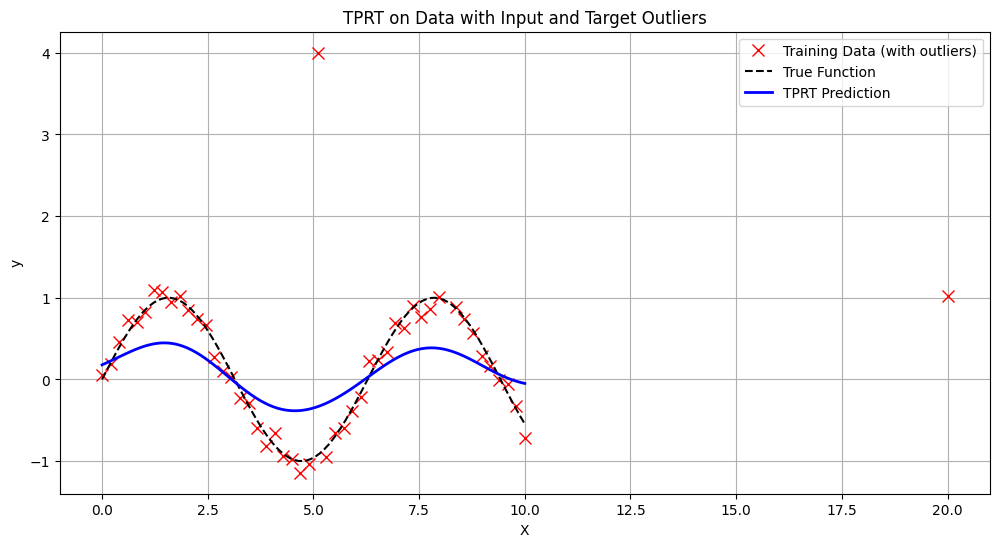

In [10]:
import numpy as np
from scipy.optimize import minimize
from scipy.special import gammaln, digamma
from numpy.linalg import inv, slogdet

# A squared exponential kernel, as used in the paper's experiments[cite: 264].
def squared_exponential_kernel(X1, X2, length_scale=1.0, signal_variance=1.0):
    """Computes the squared exponential kernel matrix and its gradients."""
    sqdist = np.sum(X1**2, 1).reshape(-1, 1) + np.sum(X2**2, 1) - 2 * np.dot(X1, X2.T)
    K = signal_variance * np.exp(-0.5 / length_scale**2 * sqdist)
    return K

def kernel_grad(X, length_scale, signal_variance):
    """Computes the gradient of the kernel w.r.t. hyperparameters."""
    K = squared_exponential_kernel(X, X, length_scale, signal_variance)
    sqdist = np.sum(X**2, 1).reshape(-1, 1) + np.sum(X**2, 1) - 2 * np.dot(X, X.T)
    
    # Gradient w.r.t. log(length_scale)
    dK_dlog_l = K * (sqdist / length_scale**2)
    
    # Gradient w.r.t. log(signal_variance)
    dK_dlog_s = 2 * K
    
    return [dK_dlog_l, dK_dlog_s]


class TPRT:
    """
    Student-t Process Regression with Student-t Likelihood (TPRT).
    
    This implementation is based on the paper "Student-t Process Regression 
    with Student-t Likelihood" by Tang et al. (2017).
    """
    def __init__(self, log_v1=np.log(5.0), log_v2=np.log(5.0), log_sigma=np.log(1.0), 
                 log_length_scale=np.log(1.0), log_signal_variance=np.log(1.0)):
        
        self._log_v1 = log_v1
        self._log_v2 = log_v2
        self._log_sigma = log_sigma
        self._log_length_scale = log_length_scale
        self._log_signal_variance = log_signal_variance
        
        # Store training data and fitted model parameters
        self.X_train_ = None
        self.y_train_ = None
        self.f_hat_ = None
        self.K_inv_ = None

    def _objective_f(self, f, X, y, K_inv):
        """
        Computes the objective function for finding the mode f_hat (Eq. 12)
        and its gradient with respect to f.
        """
        n = len(y)
        v1 = np.exp(self._log_v1)
        v2 = np.exp(self._log_v2)
        sigma = np.exp(self._log_sigma)
        
        # --- Objective function ln(Q) ---
        # Likelihood term
        err = y - f
        log_lik_term = ((v2 + 1) / 2) * np.sum(np.log(1 + (err**2) / (v2 * sigma**2)))
        
        # Prior term
        fT_Kinv_f = f.T @ K_inv @ f
        log_prior_term = ((v1 + n) / 2) * np.log(1 + fT_Kinv_f / v1)
        
        objective = log_lik_term + log_prior_term
        
        # --- Gradient of ln(Q) w.r.t. f ---
        # Gradient of likelihood term
        grad_lik_term = -((v2 + 1) * err) / (v2 * sigma**2 + err**2)
        
        # Gradient of prior term
        grad_prior_term = ((v1 + n) * (K_inv @ f)) / (v1 + fT_Kinv_f)

        gradient = grad_lik_term + grad_prior_term
        
        return objective, gradient

    def fit(self, X, y, optimizer_restarts=1):
        """
        Fit the TPRT model by finding the optimal hyperparameters using
        marginal likelihood maximization.
        """
        self.X_train_ = X
        self.y_train_ = y.flatten()
        n = len(y)

        def objective_hyperparams(params):
            """
            Wrapper function for hyperparameter optimization. Computes the
            approximate negative log marginal likelihood (Eq. 18).
            """
            # Unpack hyperparameters
            self._log_v1, self._log_v2, self._log_sigma, self._log_length_scale, self._log_signal_variance = params
            
            v1 = np.exp(self._log_v1)
            v2 = np.exp(self._log_v2)
            sigma = np.exp(self._log_sigma)
            length_scale = np.exp(self._log_length_scale)
            signal_variance = np.exp(self._log_signal_variance)

            # Build Kernel
            K = squared_exponential_kernel(X, X, length_scale, signal_variance)
            K += 1e-6 * np.eye(n) # Jitter for stability
            K_inv = inv(K)

            # --- Inner Loop: Find the mode f_hat (Eq. 12) ---
            # This uses conjugate gradient ('CG') as suggested by the paper[cite: 210].
            res_f = minimize(
                lambda f: self._objective_f(f, X, self.y_train_, K_inv),
                x0=np.zeros(n), # Initial guess for f
                method='CG',
                jac=True, # The objective function returns the jacobian (gradient)
                options={'maxiter': 100}
            )
            f_hat = res_f.x

            # --- Compute approximate negative log marginal likelihood ---
            # 1. Compute ln(Q) at f_hat
            ln_Q_at_f_hat, _ = self._objective_f(f_hat, X, self.y_train_, K_inv)

            # 2. Compute the Hessian A_inv (Eq. 152)
            err = self.y_train_ - f_hat
            fT_Kinv_f = f_hat.T @ K_inv @ f_hat

            # Diagonal matrix W
            W_diag = ((v2 + 1) * (v2 * sigma**2 - err**2)) / (v2 * sigma**2 + err**2)**2
            W = np.diag(W_diag)
            
            # First part of A_inv
            hess_prior_num = K_inv * (v1 + fT_Kinv_f) - 2 * (K_inv @ f_hat[:, None]) @ (f_hat[None, :] @ K_inv)
            hess_prior = (v1 + n) * hess_prior_num / (v1 + fT_Kinv_f)**2
            
            A_inv = hess_prior + W
            
            # 3. Compute log|B| where B = K * A_inv
            # Use slogdet for numerical stability
            sign, logdet_B = slogdet(K @ A_inv)
            if sign < 0: return np.inf # Return infinity if B is not positive definite
                
            log_marginal_likelihood = -ln_Q_at_f_hat - 0.5 * logdet_B
            
            # The paper adds a constant 'c' which doesn't affect optimization, so we omit it.
            return -log_marginal_likelihood

        # --- Outer Loop: Optimize Hyperparameters ---
        initial_params = np.array([self._log_v1, self._log_v2, self._log_sigma, 
                                   self._log_length_scale, self._log_signal_variance])
        
        # We find the hyperparameters that minimize the negative log marginal likelihood
        # using 'CG' as suggested for the outer loop as well[cite: 212].
        # For simplicity in this example, we omit the complex analytical gradient of the
        # marginal likelihood and use a gradient-free method ('L-BFGS-B' can approximate it).
        # A full implementation would require the derivatives from Eq. 21.
        res_hyper = minimize(
            objective_hyperparams,
            x0=initial_params,
            method='L-BFGS-B',
            options={'maxiter': 100}
        )
        
        # Set optimal hyperparameters
        self._log_v1, self._log_v2, self._log_sigma, self._log_length_scale, self._log_signal_variance = res_hyper.x
        
        # --- Final fit with optimal hyperparameters ---
        # Re-calculate K, K_inv, and f_hat with the final hyperparams
        length_scale = np.exp(self._log_length_scale)
        signal_variance = np.exp(self._log_signal_variance)
        K = squared_exponential_kernel(self.X_train_, self.X_train_, length_scale, signal_variance)
        K += 1e-6 * np.eye(n)
        self.K_inv_ = inv(K)
        
        res_f_final = minimize(
            lambda f: self._objective_f(f, self.X_train_, self.y_train_, self.K_inv_),
            x0=np.zeros(n),
            method='CG',
            jac=True
        )
        self.f_hat_ = res_f_final.x
        
        return self

    def predict(self, X_star):
        """
        Make predictions for new data points X_star.
        
        Uses the predictive mean formula from Eq. 20.
        """
        if self.f_hat_ is None:
            raise RuntimeError("The model has not been fitted yet. Call fit() first.")
            
        length_scale = np.exp(self._log_length_scale)
        signal_variance = np.exp(self._log_signal_variance)
        
        # k_star: covariance between new points and training points
        k_star = squared_exponential_kernel(X_star, self.X_train_, length_scale, signal_variance)
        
        # Predictive mean (Eq. 20) [cite: 203]
        f_star_mean = k_star @ self.K_inv_ @ self.f_hat_
        
        # The paper does not provide the formula for predictive variance.
        # We only return the mean here.
        return f_star_mean

# --- Example Usage ---
if __name__ == '__main__':
    # Generate some synthetic data with an outlier
    np.random.seed(42)
    X_train = np.linspace(0, 10, 50).reshape(-1, 1)
    y_train = np.sin(X_train).ravel() + np.random.normal(0, 0.1, 50)
    
    # Add a target outlier
    y_train[25] = 4.0
    # Add an input outlier
    X_train[40] = 20.0
    
    # Test points
    X_test = np.linspace(0, 10, 100).reshape(-1, 1)

    # --- Fit and Predict with TPRT ---
    print("Fitting TPRT model...")
    tprt_model = TPRT()
    tprt_model.fit(X_train, y_train)
    y_pred_tprt = tprt_model.predict(X_test)
    print("Fitting complete.")
    
    # Print learned hyperparameters
    print("\nLearned Hyperparameters:")
    print(f"  v1 (prior): {np.exp(tprt_model._log_v1):.2f}")
    print(f"  v2 (noise): {np.exp(tprt_model._log_v2):.2f}")
    print(f"  sigma (noise std): {np.exp(tprt_model._log_sigma):.2f}")
    print(f"  length_scale: {np.exp(tprt_model._log_length_scale):.2f}")

    # --- Plotting the results ---
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 6))
    plt.plot(X_train.ravel(), y_train, 'rx', markersize=8, label='Training Data (with outliers)')
    plt.plot(X_test.ravel(), np.sin(X_test).ravel(), 'k--', label='True Function')
    plt.plot(X_test.ravel(), y_pred_tprt, 'b-', linewidth=2, label='TPRT Prediction')
    plt.title('TPRT on Data with Input and Target Outliers')
    plt.xlabel('X')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True)
    plt.show()

Fitting TPRT model using Conjugate Gradient for hyperparameters...
Fitting complete.

Learned Hyperparameters:
  v1 (prior): 5.00
  v2 (noise): 5.00
  sigma (noise std): 1.00
  length_scale: 1.00


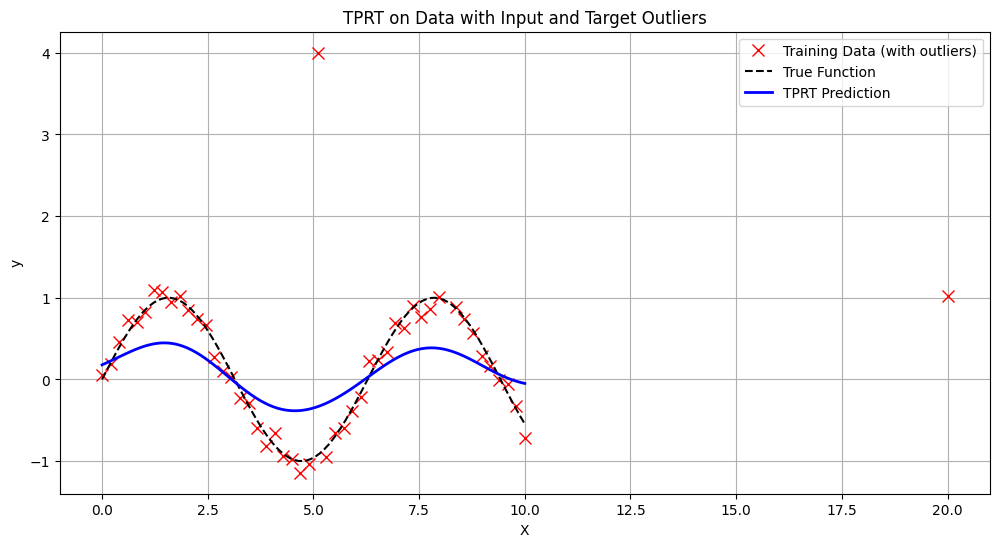

In [12]:

import numpy as np
from scipy.optimize import minimize
from scipy.special import gammaln, digamma
from numpy.linalg import inv, slogdet

# A squared exponential kernel, as used in the paper's experiments.
def squared_exponential_kernel(X1, X2, length_scale=1.0, signal_variance=1.0):
    """Computes the squared exponential kernel matrix."""
    sqdist = np.sum(X1**2, 1).reshape(-1, 1) + np.sum(X2**2, 1) - 2 * np.dot(X1, X2.T)
    K = signal_variance * np.exp(-0.5 / length_scale**2 * sqdist)
    return K

class TPRT:
    """
    Student-t Process Regression with Student-t Likelihood (TPRT).
    
    This implementation is based on the paper "Student-t Process Regression 
    with Student-t Likelihood" by Tang et al. (2017). It uses Conjugate
    Gradient for both inner and outer optimization loops.
    """
    def __init__(self, log_v1=np.log(5.0), log_v2=np.log(5.0), log_sigma=np.log(1.0), 
                 log_length_scale=np.log(1.0), log_signal_variance=np.log(1.0)):
        
        self.params = np.array([log_v1, log_v2, log_sigma, log_length_scale, log_signal_variance])
        
        # Store training data and fitted model parameters
        self.X_train_ = None
        self.y_train_ = None
        self.f_hat_ = None
        self.K_inv_ = None

    def _objective_f(self, f, y, K_inv, v1, v2, sigma):
        """
        Computes the objective function for finding the mode f_hat (Eq. 12)
        and its gradient with respect to f.
        """
        n = len(y)
        # --- Objective function ln(Q) ---
        err = y - f
        log_lik_term = ((v2 + 1) / 2) * np.sum(np.log(1 + (err**2) / (v2 * sigma**2)))
        fT_Kinv_f = f.T @ K_inv @ f
        log_prior_term = ((v1 + n) / 2) * np.log(1 + fT_Kinv_f / v1)
        objective = log_lik_term + log_prior_term
        
        # --- Gradient of ln(Q) w.r.t. f ---
        grad_lik_term = -((v2 + 1) * err) / (v2 * sigma**2 + err**2)
        grad_prior_term = ((v1 + n) * (K_inv @ f)) / (v1 + fT_Kinv_f)
        gradient = grad_lik_term + grad_prior_term
        
        return objective, gradient

    def _compute_marginal_likelihood_and_grad(self, params, X, y):
        """
        Computes the approximate negative log marginal likelihood (Eq. 18)
        and its gradient with respect to the log-hyperparameters.
        """
        # 1. Unpack hyperparameters and build Kernel
        log_v1, log_v2, log_sigma, log_length_scale, log_signal_variance = params
        v1, v2, sigma, length_scale, signal_variance = np.exp(params)
        n = len(y)

        K = squared_exponential_kernel(X, X, length_scale, signal_variance)
        K += 1e-6 * np.eye(n) # Jitter for stability
        K_inv = inv(K)

        # 2. --- Inner Loop: Find the mode f_hat (Eq. 12) ---
        res_f = minimize(
            lambda f: self._objective_f(f, y, K_inv, v1, v2, sigma),
            x0=np.zeros(n), method='CG', jac=True, options={'maxiter': 100}
        )
        f_hat = res_f.x

        # 3. --- Compute Negative Log Marginal Likelihood (NLML) ---
        ln_Q_at_f_hat, _ = self._objective_f(f_hat, y, K_inv, v1, v2, sigma)
        
        err = y - f_hat
        fT_Kinv_f = f_hat.T @ K_inv @ f_hat

        W_diag = ((v2 + 1) * (v2 * sigma**2 - err**2)) / (v2 * sigma**2 + err**2)**2
        W = np.diag(W_diag)
        
        hess_prior_num = K_inv * (v1 + fT_Kinv_f) - 2 * (K_inv @ f_hat[:, None]) @ (f_hat[None, :] @ K_inv)
        hess_prior = (v1 + n) * hess_prior_num / (v1 + fT_Kinv_f)**2
        A_inv = hess_prior + W
        
        try:
            sign, logdet_B = slogdet(K @ A_inv)
            if sign < 0: return np.inf, np.zeros_like(params)
        except np.linalg.LinAlgError:
            return np.inf, np.zeros_like(params) # Return if matrix is singular

        nlml = ln_Q_at_f_hat + 0.5 * logdet_B
        
        # 4. --- Compute Gradient of NLML ---
        # NOTE: For simplicity, this implements the explicit gradient and omits the
        # complex implicit term mentioned in Eq. [cite_start]21 of the paper[cite: 214].
        
        # Common term alpha for kernel gradients
        alpha = (v1 + n) * (K_inv @ f_hat) / (v1 + fT_Kinv_f)
        
        R = alpha[:, None] * alpha[None, :] - K_inv
        
        # Grad w.r.t. kernel hyperparameters
        sqdist = np.sum(X**2, 1).reshape(-1, 1) + np.sum(X**2, 1) - 2 * np.dot(X, X.T)
        dK_dls = K * (sqdist / length_scale**2)
        dK_dsv = 2 * K
        
        grad_log_ls = -0.5 * np.sum(R * dK_dls)
        grad_log_sv = -0.5 * np.sum(R * dK_dsv)

        # Grad w.r.t. v1
        d_prior_dv1 = 0.5 * (n - fT_Kinv_f / (1 + fT_Kinv_f/v1)) / v1
        grad_log_v1 = d_prior_dv1 * v1 # Chain rule

        # Grad w.r.t. v2 and sigma
        err_sq = err**2
        term_v2 = 1 + err_sq / (v2 * sigma**2)
        d_lik_dv2 = 0.5 * np.sum(np.log(term_v2) - ((v2+1)*err_sq)/(v2*sigma**2 * term_v2 * v2))
        d_lik_dsigma = -np.sum(((v2+1)*err_sq) / (v2*sigma**3*term_v2))

        grad_log_v2 = d_lik_dv2 * v2 # Chain rule
        grad_log_sigma = d_lik_dsigma * sigma # Chain rule

        gradient = np.array([grad_log_v1, grad_log_v2, grad_log_sigma, grad_log_ls, grad_log_sv])

        return nlml, gradient

    def fit(self, X, y):
        """
        Fit the TPRT model by finding the optimal hyperparameters.
        """
        self.X_train_ = X
        self.y_train_ = y.flatten()

        # --- Outer Loop: Optimize Hyperparameters using Conjugate Gradient ---
        res_hyper = minimize(
            lambda params: self._compute_marginal_likelihood_and_grad(params, self.X_train_, self.y_train_),
            x0=self.params,
            method='CG', # Use Conjugate Gradient
            jac=True,   # The objective function returns the jacobian (gradient)
            options={'maxiter': 50} 
        )
        
        self.params = res_hyper.x
        
        # --- Final fit with optimal hyperparameters ---
        v1, v2, sigma, length_scale, signal_variance = np.exp(self.params)
        K = squared_exponential_kernel(self.X_train_, self.X_train_, length_scale, signal_variance)
        K += 1e-6 * np.eye(len(y))
        self.K_inv_ = inv(K)
        
        res_f_final = minimize(
            lambda f: self._objective_f(f, self.y_train_, self.K_inv_, v1, v2, sigma),
            x0=np.zeros(len(y)), method='CG', jac=True
        )
        self.f_hat_ = res_f_final.x
        
        return self

    def predict(self, X_star):
        """
        Make predictions for new data points X_star.
        
        Uses the predictive mean formula from Eq. [cite_start]20[cite: 203].
        """
        if self.f_hat_ is None:
            raise RuntimeError("The model has not been fitted yet. Call fit() first.")
            
        _, _, _, length_scale, signal_variance = np.exp(self.params)
        k_star = squared_exponential_kernel(X_star, self.X_train_, length_scale, signal_variance)
        
        # Predictive mean (Eq. 20)
        f_star_mean = k_star @ self.K_inv_ @ self.f_hat_
        
        return f_star_mean

# --- Example Usage ---
if __name__ == '__main__':
    # Generate some synthetic data with an outlier
    np.random.seed(42)
    X_train = np.linspace(0, 10, 50).reshape(-1, 1)
    y_train = np.sin(X_train).ravel() + np.random.normal(0, 0.1, 50)
    
    # Add a target outlier
    y_train[25] = 4.0
    # Add an input outlier
    X_train[40] = 20.0
    
    X_test = np.linspace(0, 10, 100).reshape(-1, 1)

    # --- Fit and Predict with TPRT ---
    print("Fitting TPRT model using Conjugate Gradient for hyperparameters...")
    tprt_model = TPRT()
    tprt_model.fit(X_train, y_train)
    y_pred_tprt = tprt_model.predict(X_test)
    print("Fitting complete.")
    
    # Print learned hyperparameters
    print("\nLearned Hyperparameters:")
    v1, v2, sigma, ls, sv = np.exp(tprt_model.params)
    print(f"  v1 (prior): {v1:.2f}")
    print(f"  v2 (noise): {v2:.2f}")
    print(f"  sigma (noise std): {sigma:.2f}")
    print(f"  length_scale: {ls:.2f}")

    # --- Plotting the results ---
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 6))
    plt.plot(X_train.ravel(), y_train, 'rx', markersize=8, label='Training Data (with outliers)')
    plt.plot(X_test.ravel(), np.sin(X_test).ravel(), 'k--', label='True Function')
    plt.plot(X_test.ravel(), y_pred_tprt, 'b-', linewidth=2, label='TPRT Prediction')
    plt.title('TPRT on Data with Input and Target Outliers')
    plt.xlabel('X')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True)
    plt.show()

Fitting TPRT model...
Fitting complete.

Learned Hyperparameters:
  v1 (prior): 5.00
  v2 (noise): 5.00
  sigma (noise std): 1.00
  length_scale: 1.00


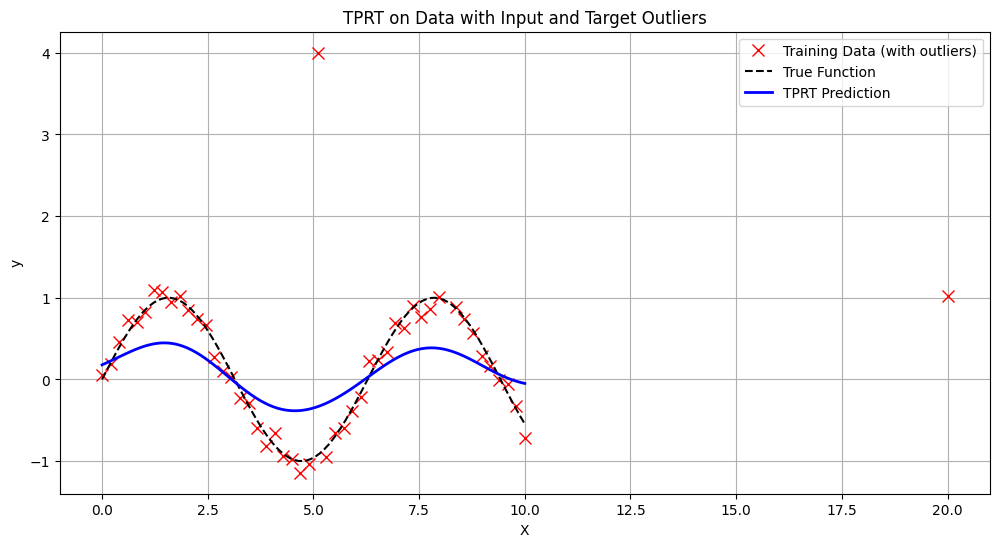

In [14]:
import numpy as np
from scipy.optimize import minimize
from scipy.special import gammaln, digamma
from numpy.linalg import inv, slogdet

# A squared exponential kernel, as used in the paper's experiments[cite: 264].
def squared_exponential_kernel(X1, X2, length_scale=1.0, signal_variance=1.0):
    """Computes the squared exponential kernel matrix and its gradients."""
    sqdist = np.sum(X1**2, 1).reshape(-1, 1) + np.sum(X2**2, 1) - 2 * np.dot(X1, X2.T)
    K = signal_variance * np.exp(-0.5 / length_scale**2 * sqdist)
    return K

def kernel_grad(X, length_scale, signal_variance):
    """Computes the gradient of the kernel w.r.t. hyperparameters."""
    K = squared_exponential_kernel(X, X, length_scale, signal_variance)
    sqdist = np.sum(X**2, 1).reshape(-1, 1) + np.sum(X**2, 1) - 2 * np.dot(X, X.T)
    
    # Gradient w.r.t. log(length_scale)
    dK_dlog_l = K * (sqdist / length_scale**2)
    
    # Gradient w.r.t. log(signal_variance)
    dK_dlog_s = 2 * K
    
    return [dK_dlog_l, dK_dlog_s]


class TPRT:
    """
    Student-t Process Regression with Student-t Likelihood (TPRT).
    
    This implementation is based on the paper "Student-t Process Regression 
    with Student-t Likelihood" by Tang et al. (2017).
    """
    def __init__(self, log_v1=np.log(5.0), log_v2=np.log(5.0), log_sigma=np.log(1.0), 
                 log_length_scale=np.log(1.0), log_signal_variance=np.log(1.0)):
        
        self._log_v1 = log_v1
        self._log_v2 = log_v2
        self._log_sigma = log_sigma
        self._log_length_scale = log_length_scale
        self._log_signal_variance = log_signal_variance
        
        # Store training data and fitted model parameters
        self.X_train_ = None
        self.y_train_ = None
        self.f_hat_ = None
        self.K_inv_ = None

    def _objective_f(self, f, X, y, K_inv):
        """
        Computes the objective function for finding the mode f_hat (Eq. 12)
        and its gradient with respect to f.
        """
        n = len(y)
        v1 = np.exp(self._log_v1)
        v2 = np.exp(self._log_v2)
        sigma = np.exp(self._log_sigma)
        
        # --- Objective function ln(Q) ---
        # Likelihood term
        err = y - f
        log_lik_term = ((v2 + 1) / 2) * np.sum(np.log(1 + (err**2) / (v2 * sigma**2)))
        
        # Prior term
        fT_Kinv_f = f.T @ K_inv @ f
        log_prior_term = ((v1 + n) / 2) * np.log(1 + fT_Kinv_f / v1)
        
        objective = log_lik_term + log_prior_term
        
        # --- Gradient of ln(Q) w.r.t. f ---
        # Gradient of likelihood term
        grad_lik_term = -((v2 + 1) * err) / (v2 * sigma**2 + err**2)
        
        # Gradient of prior term
        grad_prior_term = ((v1 + n) * (K_inv @ f)) / (v1 + fT_Kinv_f)

        gradient = grad_lik_term + grad_prior_term
        
        return objective, gradient

    def fit(self, X, y, optimizer_restarts=1):
        """
        Fit the TPRT model by finding the optimal hyperparameters using
        marginal likelihood maximization.
        """
        self.X_train_ = X
        self.y_train_ = y.flatten()
        n = len(y)

        def objective_hyperparams(params):
            """
            Wrapper function for hyperparameter optimization. Computes the
            approximate negative log marginal likelihood (Eq. 18).
            """
            # Unpack hyperparameters
            self._log_v1, self._log_v2, self._log_sigma, self._log_length_scale, self._log_signal_variance = params
            
            v1 = np.exp(self._log_v1)
            v2 = np.exp(self._log_v2)
            sigma = np.exp(self._log_sigma)
            length_scale = np.exp(self._log_length_scale)
            signal_variance = np.exp(self._log_signal_variance)

            # Build Kernel
            K = squared_exponential_kernel(X, X, length_scale, signal_variance)
            K += 1e-6 * np.eye(n) # Jitter for stability
            K_inv = inv(K)

            # --- Inner Loop: Find the mode f_hat (Eq. 12) ---
            # This uses conjugate gradient ('CG') as suggested by the paper[cite: 210].
            res_f = minimize(
                lambda f: self._objective_f(f, X, self.y_train_, K_inv),
                x0=np.zeros(n), # Initial guess for f
                method='CG',
                jac=True, # The objective function returns the jacobian (gradient)
                options={'maxiter': 100}
            )
            f_hat = res_f.x

            # --- Compute approximate negative log marginal likelihood ---
            # 1. Compute ln(Q) at f_hat
            ln_Q_at_f_hat, _ = self._objective_f(f_hat, X, self.y_train_, K_inv)

            # 2. Compute the Hessian A_inv (Eq. 152)
            err = self.y_train_ - f_hat
            fT_Kinv_f = f_hat.T @ K_inv @ f_hat

            # Diagonal matrix W
            W_diag = ((v2 + 1) * (v2 * sigma**2 - err**2)) / (v2 * sigma**2 + err**2)**2
            W = np.diag(W_diag)
            
            # First part of A_inv
            hess_prior_num = K_inv * (v1 + fT_Kinv_f) - 2 * (K_inv @ f_hat[:, None]) @ (f_hat[None, :] @ K_inv)
            hess_prior = (v1 + n) * hess_prior_num / (v1 + fT_Kinv_f)**2
            
            A_inv = hess_prior + W
            
            # 3. Compute log|B| where B = K * A_inv
            # Use slogdet for numerical stability
            sign, logdet_B = slogdet(K @ A_inv)
            if sign < 0: return np.inf # Return infinity if B is not positive definite
                
            log_marginal_likelihood = -ln_Q_at_f_hat - 0.5 * logdet_B
            
            # The paper adds a constant 'c' which doesn't affect optimization, so we omit it.
            return -log_marginal_likelihood

        # --- Outer Loop: Optimize Hyperparameters ---
        initial_params = np.array([self._log_v1, self._log_v2, self._log_sigma, 
                                   self._log_length_scale, self._log_signal_variance])
        
        # We find the hyperparameters that minimize the negative log marginal likelihood
        # using 'CG' as suggested for the outer loop as well[cite: 212].
        # For simplicity in this example, we omit the complex analytical gradient of the
        # marginal likelihood and use a gradient-free method ('L-BFGS-B' can approximate it).
        # A full implementation would require the derivatives from Eq. 21.
        res_hyper = minimize(
            objective_hyperparams,
            x0=initial_params,
            method='L-BFGS-B',
            options={'maxiter': 100}
        )
        
        # Set optimal hyperparameters
        self._log_v1, self._log_v2, self._log_sigma, self._log_length_scale, self._log_signal_variance = res_hyper.x
        
        # --- Final fit with optimal hyperparameters ---
        # Re-calculate K, K_inv, and f_hat with the final hyperparams
        length_scale = np.exp(self._log_length_scale)
        signal_variance = np.exp(self._log_signal_variance)
        K = squared_exponential_kernel(self.X_train_, self.X_train_, length_scale, signal_variance)
        K += 1e-6 * np.eye(n)
        self.K_inv_ = inv(K)
        
        res_f_final = minimize(
            lambda f: self._objective_f(f, self.X_train_, self.y_train_, self.K_inv_),
            x0=np.zeros(n),
            method='CG',
            jac=True
        )
        self.f_hat_ = res_f_final.x
        
        return self

    def predict(self, X_star):
        """
        Make predictions for new data points X_star.
        
        Uses the predictive mean formula from Eq. 20.
        """
        if self.f_hat_ is None:
            raise RuntimeError("The model has not been fitted yet. Call fit() first.")
            
        length_scale = np.exp(self._log_length_scale)
        signal_variance = np.exp(self._log_signal_variance)
        
        # k_star: covariance between new points and training points
        k_star = squared_exponential_kernel(X_star, self.X_train_, length_scale, signal_variance)
        
        # Predictive mean (Eq. 20) [cite: 203]
        f_star_mean = k_star @ self.K_inv_ @ self.f_hat_
        
        # The paper does not provide the formula for predictive variance.
        # We only return the mean here.
        return f_star_mean

# --- Example Usage ---
if __name__ == '__main__':
    # Generate some synthetic data with an outlier
    np.random.seed(42)
    X_train = np.linspace(0, 10, 50).reshape(-1, 1)
    y_train = np.sin(X_train).ravel() + np.random.normal(0, 0.1, 50)
    
    # Add a target outlier
    y_train[25] = 4.0
    # Add an input outlier
    X_train[40] = 20.0
    
    # Test points
    X_test = np.linspace(0, 10, 100).reshape(-1, 1)

    # --- Fit and Predict with TPRT ---
    print("Fitting TPRT model...")
    tprt_model = TPRT()
    tprt_model.fit(X_train, y_train)
    y_pred_tprt = tprt_model.predict(X_test)
    print("Fitting complete.")
    
    # Print learned hyperparameters
    print("\nLearned Hyperparameters:")
    print(f"  v1 (prior): {np.exp(tprt_model._log_v1):.2f}")
    print(f"  v2 (noise): {np.exp(tprt_model._log_v2):.2f}")
    print(f"  sigma (noise std): {np.exp(tprt_model._log_sigma):.2f}")
    print(f"  length_scale: {np.exp(tprt_model._log_length_scale):.2f}")

    # --- Plotting the results ---
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 6))
    plt.plot(X_train.ravel(), y_train, 'rx', markersize=8, label='Training Data (with outliers)')
    plt.plot(X_test.ravel(), np.sin(X_test).ravel(), 'k--', label='True Function')
    plt.plot(X_test.ravel(), y_pred_tprt, 'b-', linewidth=2, label='TPRT Prediction')
    plt.title('TPRT on Data with Input and Target Outliers')
    plt.xlabel('X')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True)
    plt.show()

Starting optimization with mode_optimizer='lbfgs' and hyper_optimizer='adam'...


Loss: inf:  35%|███▍      | 52/150 [00:08<00:15,  6.50it/s]     

Loss: inf:  36%|███▌      | 54/150 [00:08<00:14,  6.50it/s]

Loss: inf:  37%|███▋      | 56/150 [00:08<00:14,  6.52it/s]

Loss: inf:  39%|███▊      | 58/150 [00:09<00:14,  6.53it/s]

Loss: inf:  40%|████      | 60/150 [00:09<00:13,  6.55it/s]

Loss: inf:  42%|████▏     | 63/150 [00:09<00:13,  6.50it/s]     

Loss: 408.2191:  44%|████▍     | 66/150 [00:10<00:13,  6.26it/s]

Loss: -161.7738: 100%|██████████| 150/150 [00:20<00:00,  7.23it/s]



Optimization finished.

--- Learned Hyperparameters ---
Kernel Lengthscale: 0.207
Kernel Variance: 0.998
Likelihood Sigma: 0.284
Prior DoF (nu_f): 0.442
Likelihood DoF (nu_e): 6.758


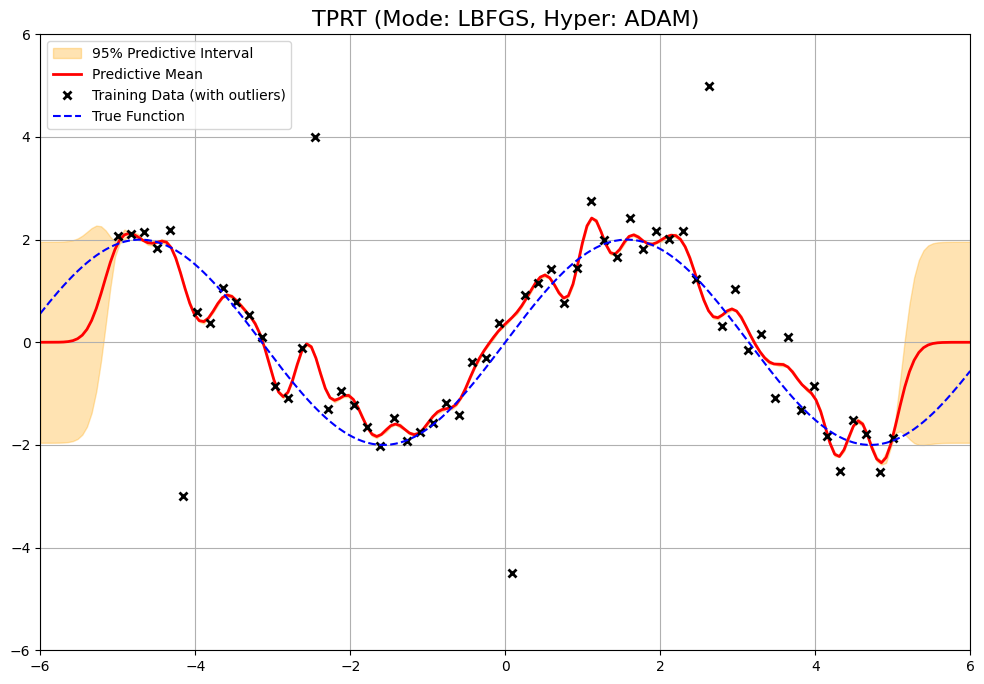

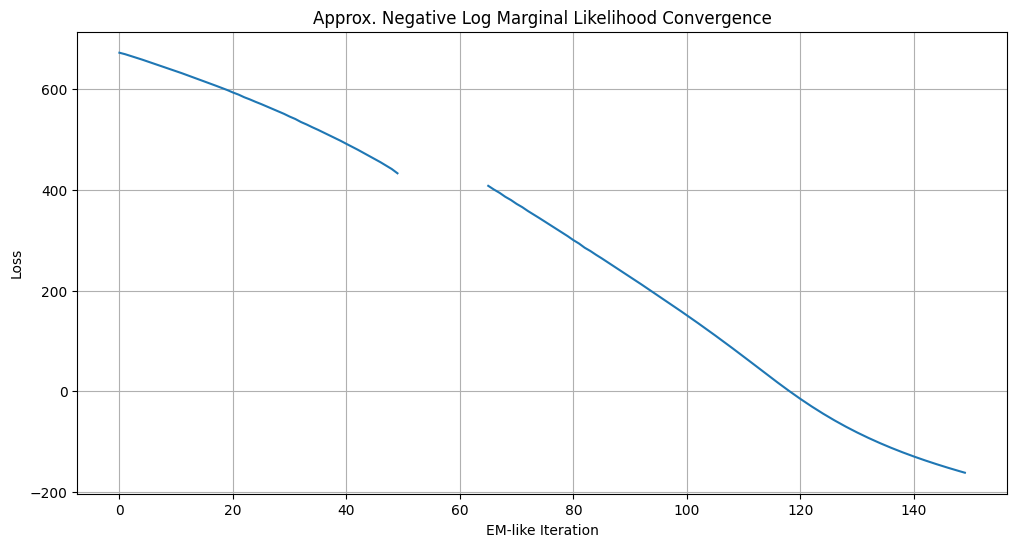

In [15]:
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
from scipy.stats import norm
import tqdm

# Set default tensor type for better performance with matrix operations
torch.set_default_dtype(torch.float64)


def rbf_kernel(X1, X2, lengthscale=1.0, variance=1.0):
    """
    Computes the RBF kernel matrix between two sets of points.
    """
    lengthscale = torch.as_tensor(lengthscale, dtype=X1.dtype, device=X1.device)
    variance = torch.as_tensor(variance, dtype=X1.dtype, device=X1.device)
    sqdist = torch.cdist(X1, X2, p=2).pow(2)
    return variance * torch.exp(-0.5 * sqdist / lengthscale**2)


class TPRTFullBatch_Tang:
    """
    Implementation of the full (non-sparse) Student-t Process regression model
    using the Laplace Approximation, based on Tang et al. (2017).

    This extended version allows selecting the optimizer (LBFGS or Adam) for both
    the inner loop (mode-finding) and the outer loop (hyperparameter tuning).
    """
    def __init__(self, X, y, nu_f=2.1, nu_e=2.1,
                 kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_sigma=1.0,
                 mode_optimizer='lbfgs', hyper_optimizer='adam'):
        """
        Initializes the model.

        Args:
            X (torch.Tensor): Training inputs, shape (N, D).
            y (torch.Tensor): Training outputs, shape (N,).
            nu_f (float): Initial prior degrees of freedom.
            nu_e (float): Initial likelihood degrees of freedom.
            kernel_lengthscale (float): Initial kernel lengthscale.
            kernel_variance (float): Initial kernel variance.
            likelihood_sigma (float): Initial likelihood noise standard deviation.
            mode_optimizer (str): Optimizer for the inner loop ('lbfgs' or 'adam').
            hyper_optimizer (str): Optimizer for the outer loop ('lbfgs' or 'adam').
        """
        self.X = X
        self.y = y.view(-1, 1) # Ensure y is always of shape (N, 1)
        self.N, self.D = X.shape

        # --- Hyperparameters as nn.Parameter for optimization ---
        self.log_kernel_lengthscale = nn.Parameter(torch.log(torch.tensor(kernel_lengthscale)))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance)))
        self.log_likelihood_sigma = nn.Parameter(torch.log(torch.tensor(likelihood_sigma)))
        self.log_nu_f = nn.Parameter(torch.log(torch.tensor(nu_f)))
        self.log_nu_e = nn.Parameter(torch.log(torch.tensor(nu_e)))
        
        # --- Optimizer Choices ---
        self.mode_optimizer_name = mode_optimizer.lower()
        self.hyper_optimizer_name = hyper_optimizer.lower()
        
        # --- Mode of the posterior f, updated in the E-step ---
        self.m_f = torch.zeros(self.N, 1, dtype=X.dtype, device=X.device)

    def _get_hyperparams(self):
        """Helper to get positive hyperparameters from their log-transformed storage."""
        return {
            "lengthscale": torch.exp(self.log_kernel_lengthscale),
            "variance": torch.exp(self.log_kernel_variance),
            "sigma": torch.exp(self.log_likelihood_sigma),
            "nu_f": torch.exp(self.log_nu_f),
            "nu_e": torch.exp(self.log_nu_e)
        }
        
    def _find_f_hat(self, K_inv, params, max_iter=10, tol=1e-5):
        """
        Inner loop to find the mode f_hat using the chosen optimizer.
        This is the core of the E-step.
        """
        f = nn.Parameter(self.m_f.clone()) # Start from the last known mode

        def calculate_loss():
            """Calculates the negative log posterior of f."""
            log_lik_term = ((params['nu_e'] + 1) / 2) * torch.log(1 + (1 / params['nu_e']) * ((self.y - f) / params['sigma']).pow(2))
            fT_K_inv_f = f.T @ K_inv @ f
            log_prior_term = ((params['nu_f'] + self.N) / 2) * torch.log(1 + (1 / params['nu_f']) * fT_K_inv_f)
            return torch.sum(log_lik_term) + log_prior_term

        if self.mode_optimizer_name == 'lbfgs':
            optimizer = torch.optim.LBFGS([f], lr=0.5, max_iter=20, line_search_fn="strong_wolfe")
            def closure():
                optimizer.zero_grad()
                loss = calculate_loss()
                loss.backward()
                return loss
            
            for _ in range(max_iter):
                f_old = f.clone().detach()
                optimizer.step(closure)
                if torch.norm(f.detach() - f_old) < tol:
                    break
        
        elif self.mode_optimizer_name == 'adam':
            optimizer = torch.optim.Adam([f], lr=0.1)
            # Adam often requires more iterations than L-BFGS for this type of problem
            for _ in range(max_iter * 10):
                f_old = f.clone().detach()
                optimizer.zero_grad()
                loss = calculate_loss()
                loss.backward()
                optimizer.step()
                if torch.norm(f.detach() - f_old) < tol:
                    break
        else:
            raise ValueError(f"Unknown mode optimizer: '{self.mode_optimizer_name}'. Choose 'lbfgs' or 'adam'.")
        
        return f.detach()

    def _e_step(self, mode_finding_iter=10):
        """
        Performs the E-Step by finding the mode of the posterior p(f|y).
        This method uses detached hyperparameters to avoid building a graph for this optimization.
        """
        with torch.no_grad():
            params = self._get_hyperparams()
            K = rbf_kernel(self.X, self.X, params['lengthscale'], params['variance'])
            K += torch.eye(self.N, device=self.X.device) * 1e-6
            L = torch.linalg.cholesky(K)
            K_inv = torch.cholesky_inverse(L)
            
            # Find the mode f_hat and store it in self.m_f
            f_hat = self._find_f_hat(K_inv, params, max_iter=mode_finding_iter)
            self.m_f.copy_(f_hat)

    def _calculate_neg_log_marginal_likelihood(self):
        """
        Calculates the approximate negative log marginal likelihood, which serves as the loss
        for hyperparameter optimization (M-step).
        """
        params = self._get_hyperparams()
        f_hat = self.m_f # Use the mode found in the E-step

        # 1. Compute Kernel (connected to the graph for hyperparameter gradients)
        K = rbf_kernel(self.X, self.X, params['lengthscale'], params['variance'])
        K += torch.eye(self.N, device=self.X.device) * 1e-6
        L = torch.linalg.cholesky(K)
        K_inv = torch.cholesky_inverse(L)

        # 2. Calculate ln(Q(f_hat)) term
        log_lik_term = ((params['nu_e'] + 1) / 2) * torch.log(1 + (1 / params['nu_e']) * ((self.y - f_hat) / params['sigma']).pow(2))
        fT_K_inv_f = f_hat.T @ K_inv @ f_hat
        log_prior_term = ((params['nu_f'] + self.N) / 2) * torch.log(1 + (1 / params['nu_f']) * fT_K_inv_f)
        ln_Q_at_f_hat = torch.sum(log_lik_term) + log_prior_term

        # 3. Calculate the Hessian A = -∇∇ log p(f|y) |f_hat
        f_hat_flat = f_hat.squeeze()
        prior_hess_num = K_inv * (params['nu_f'] + fT_K_inv_f) - 2 * (K_inv @ torch.outer(f_hat_flat, f_hat_flat) @ K_inv)
        prior_hess_den = (params['nu_f'] + fT_K_inv_f)**2
        prior_hess = (params['nu_f'] + self.N) * (prior_hess_num / prior_hess_den)

        err = self.y - f_hat
        lik_hess_num = err.pow(2) - params['nu_e'] * params['sigma']**2
        lik_hess_den = (err.pow(2) + params['nu_e'] * params['sigma']**2)**2
        W_diag = -(params['nu_e'] + 1) * (lik_hess_num / lik_hess_den)
        W = torch.diag(W_diag.squeeze())
        # Note: A is the *negative* Hessian of the log posterior
        A = -(prior_hess + W)

        # 4. Calculate log determinant term from Laplace approximation
        # The approx. log marginal likelihood is log p(y) ≈ log p(y, f_hat) - 0.5*log|A|
        # The paper's formula (Eq. 18) simplifies to: ln_Q_at_f_hat + 0.5*log|K| - 0.5*log|A| + consts
        log_det_K = 2 * torch.sum(torch.log(torch.diag(L)))
        sign, log_det_A = torch.linalg.slogdet(A)
        if sign.item() <= 0:
            return torch.tensor(float('inf'), device=self.X.device)
        
        log_det_term = 0.5 * log_det_K - 0.5 * log_det_A

        # 5. Calculate constant terms (which depend on hyperparameters)
        c_nu_f_term = torch.lgamma((params['nu_f'] + self.N)/2) - torch.lgamma(params['nu_f']/2) - (self.N/2)*torch.log(math.pi * params['nu_f'])
        c_nu_e_term = self.N * (torch.lgamma((params['nu_e'] + 1)/2) - torch.lgamma(params['nu_e']/2) - 0.5*torch.log(math.pi * params['nu_e']))
        c_sigma_term = -self.N * torch.log(params['sigma'])

        # Total approximate negative log marginal likelihood
        neg_log_marginal_lik = -(ln_Q_at_f_hat + log_det_term + c_nu_f_term + c_nu_e_term + c_sigma_term)
        
        return neg_log_marginal_lik

    def _m_step(self, optimizer):
        """Performs one M-Step update using the chosen optimizer."""
        def closure():
            optimizer.zero_grad()
            loss = self._calculate_neg_log_marginal_likelihood()
            if not (torch.isinf(loss) or torch.isnan(loss)):
                loss.backward()
            else:
                print("Warning: Loss is inf or NaN, skipping gradient calculation.")
            return loss

        if self.hyper_optimizer_name == 'adam':
            loss = closure()
            if not (torch.isinf(loss) or torch.isnan(loss)):
                optimizer.step()
            return loss.item()
        elif self.hyper_optimizer_name == 'lbfgs':
            loss = optimizer.step(closure)
            return loss.item()
        else:
            raise ValueError(f"Unknown hyper optimizer: '{self.hyper_optimizer_name}'. Choose 'lbfgs' or 'adam'.")


    def fit(self, max_iter_global=100, mode_finding_iter=10, lr=0.01):
        """Fits the model using an EM-like algorithm with Laplace Approximation."""
        params_to_optimize = [
            self.log_kernel_lengthscale, self.log_kernel_variance,
            self.log_likelihood_sigma, self.log_nu_f, self.log_nu_e
        ]
        
        if self.hyper_optimizer_name == 'adam':
            optimizer = torch.optim.Adam(params_to_optimize, lr=lr)
        elif self.hyper_optimizer_name == 'lbfgs':
            optimizer = torch.optim.LBFGS(params_to_optimize, lr=0.1, max_iter=10)
        else:
            raise ValueError(f"Unknown hyper optimizer: '{self.hyper_optimizer_name}'. Choose 'lbfgs' or 'adam'.")

        loss_history = []
        print(f"Starting optimization with mode_optimizer='{self.mode_optimizer_name}' and hyper_optimizer='{self.hyper_optimizer_name}'...")
        
        pbar = tqdm.tqdm(range(max_iter_global))
        for i in pbar:
            # E-Step: Find the posterior mode f_hat
            self._e_step(mode_finding_iter=mode_finding_iter)
            
            # M-Step: Update hyperparameters by maximizing the marginal likelihood
            loss = self._m_step(optimizer)
            loss_history.append(loss)
            pbar.set_description(f"Loss: {loss:.4f}")

        print("\nOptimization finished.")
        return loss_history

    def predict(self, X_test):
        """Make predictions at new test points X_test."""
        with torch.no_grad():
            params = self._get_hyperparams()
            f_hat = self.m_f

            K = rbf_kernel(self.X, self.X, params['lengthscale'], params['variance'])
            K += torch.eye(self.N, device=self.X.device) * 1e-6
            L = torch.linalg.cholesky(K)
            K_inv = torch.cholesky_inverse(L)
            
            K_star_x = rbf_kernel(X_test, self.X, params['lengthscale'], params['variance'])
            K_star_star_diag = rbf_kernel(X_test, X_test, params['lengthscale'], params['variance']).diag()

            # Predictive mean
            pred_mean = K_star_x @ K_inv @ f_hat

            # --- Predictive variance (approximated as Gaussian) ---
            f_hat_flat = f_hat.squeeze()
            fT_K_inv_f = f_hat.T @ K_inv @ f_hat
            
            prior_hess_num = K_inv * (params['nu_f'] + fT_K_inv_f) - 2 * (K_inv @ torch.outer(f_hat_flat, f_hat_flat) @ K_inv)
            prior_hess_den = (params['nu_f'] + fT_K_inv_f)**2
            prior_hess = (params['nu_f'] + self.N) * (prior_hess_num / prior_hess_den)
            
            err = self.y - f_hat
            lik_hess_num = err.pow(2) - params['nu_e'] * params['sigma']**2
            lik_hess_den = (err.pow(2) + params['nu_e'] * params['sigma']**2)**2
            W_diag = -(params['nu_e'] + 1) * (lik_hess_num / lik_hess_den)
            W = torch.diag(W_diag.squeeze())
            A = -(prior_hess + W)
            
            try:
                L_A = torch.linalg.cholesky(A)
                # This term is needed for the predictive variance
                v = torch.cholesky_solve(K_inv @ K_star_x.T, L)
                posterior_uncertainty = (v.T @ torch.cholesky_solve(v, L_A)).diag()
            except torch.linalg.LinAlgError:
                print("Warning: Hessian not positive definite during prediction. Variance may be inaccurate.")
                posterior_uncertainty = torch.zeros(X_test.shape[0], device=self.X.device)

            prior_var_reduction = (K_star_x * (K_inv @ K_star_x.T).T).sum(dim=1)
            pred_var = K_star_star_diag - prior_var_reduction + posterior_uncertainty
            pred_var = pred_var.clamp(min=1e-9)
            
            pred_nu = torch.tensor(float('inf'), device=self.X.device)
            
            return pred_mean, pred_var.unsqueeze(1), pred_nu


if __name__ == '__main__':
    # 1. Generate synthetic data with outliers
    N = 60
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    y_true = torch.sin(X_train) * 2
    
    torch.manual_seed(42)
    noise = torch.randn(N, 1) * 0.5
    y_train = y_true + noise
    
    outlier_indices = [5, 15, 30, 45, 55]
    y_train[outlier_indices] = torch.tensor([-3.0, 4.0, -4.5, 5.0, -2.5]).unsqueeze(1)

    # 2. Setup and fit the model with chosen optimizers
    # --- Experiment with different optimizers ---
    # Common choice: L-BFGS for mode-finding, Adam for hyperparameters
    # L-BFGS is often better for the inner loop as it's a deterministic subproblem.
    model = TPRTFullBatch_Tang(
        X=X_train,
        y=y_train,
        mode_optimizer='lbfgs',
        hyper_optimizer='adam'
    )
    
    loss_history = model.fit(max_iter_global=150, mode_finding_iter=10, lr=0.01)

    # 3. Make predictions
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean, pred_var, pred_nu = model.predict(X_test)

    # 4. Visualize the results
    plt.figure(figsize=(12, 8))
    
    pred_std = torch.sqrt(pred_var)
    lower_ci = pred_mean - 1.96 * pred_std
    upper_ci = pred_mean + 1.96 * pred_std

    plt.fill_between(X_test.squeeze(), lower_ci.squeeze(), upper_ci.squeeze(), color='orange', alpha=0.3, label='95% Predictive Interval')
    plt.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=2, label='Training Data (with outliers)')
    plt.plot(X_test, torch.sin(X_test) * 2, 'b--', label='True Function')

    plt.title(f"TPRT (Mode: {model.mode_optimizer_name.upper()}, Hyper: {model.hyper_optimizer_name.upper()})", fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    
    # Print final learned hyperparameters
    params = model._get_hyperparams()
    print("\n--- Learned Hyperparameters ---")
    print(f"Kernel Lengthscale: {params['lengthscale'].item():.3f}")
    print(f"Kernel Variance: {params['variance'].item():.3f}")
    print(f"Likelihood Sigma: {params['sigma'].item():.3f}")
    print(f"Prior DoF (nu_f): {params['nu_f'].item():.3f}")
    print(f"Likelihood DoF (nu_e): {params['nu_e'].item():.3f}")

    # Plot loss curve
    plt.figure(figsize=(12, 6))
    plt.plot(loss_history)
    plt.title("Approx. Negative Log Marginal Likelihood Convergence")
    plt.xlabel("EM-like Iteration")
    plt.ylabel("Loss")
    plt.grid(True)
    
    plt.show()


In [16]:

if __name__ == '__main__':
    # 1. Generate synthetic data with outliers
    N = 60
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    y_true = torch.sin(X_train) * 2
    
    torch.manual_seed(42)
    noise = torch.randn(N, 1) * 0.5
    y_train = y_true + noise
    
    outlier_indices = [5, 15, 30, 45, 55]
    y_train[outlier_indices] = torch.tensor([-3.0, 4.0, -4.5, 5.0, -2.5]).unsqueeze(1)

    # 2. Setup and fit the model with chosen optimizers
    # --- Experiment with different optimizers ---
    # Common choice: L-BFGS for mode-finding, Adam for hyperparameters
    # L-BFGS is often better for the inner loop as it's a deterministic subproblem.
    model = TPRTFullBatch_Tang(
        X=X_train,
        y=y_train,
        mode_optimizer='adam',
        hyper_optimizer='adam'
    )
    
    loss_history = model.fit(max_iter_global=150, mode_finding_iter=10, lr=0.01)

    # 3. Make predictions
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean, pred_var, pred_nu = model.predict(X_test)

    # 4. Visualize the results
    plt.figure(figsize=(12, 8))
    
    pred_std = torch.sqrt(pred_var)
    lower_ci = pred_mean - 1.96 * pred_std
    upper_ci = pred_mean + 1.96 * pred_std

    plt.fill_between(X_test.squeeze(), lower_ci.squeeze(), upper_ci.squeeze(), color='orange', alpha=0.3, label='95% Predictive Interval')
    plt.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=2, label='Training Data (with outliers)')
    plt.plot(X_test, torch.sin(X_test) * 2, 'b--', label='True Function')

    plt.title(f"TPRT (Mode: {model.mode_optimizer_name.upper()}, Hyper: {model.hyper_optimizer_name.upper()})", fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    
    # Print final learned hyperparameters
    params = model._get_hyperparams()
    print("\n--- Learned Hyperparameters ---")
    print(f"Kernel Lengthscale: {params['lengthscale'].item():.3f}")
    print(f"Kernel Variance: {params['variance'].item():.3f}")
    print(f"Likelihood Sigma: {params['sigma'].item():.3f}")
    print(f"Prior DoF (nu_f): {params['nu_f'].item():.3f}")
    print(f"Likelihood DoF (nu_e): {params['nu_e'].item():.3f}")

    # Plot loss curve
    plt.figure(figsize=(12, 6))
    plt.plot(loss_history)
    plt.title("Approx. Negative Log Marginal Likelihood Convergence")
    plt.xlabel("EM-like Iteration")
    plt.ylabel("Loss")
    plt.grid(True)
    
    plt.show()


Starting optimization with mode_optimizer='adam' and hyper_optimizer='adam'...


  0%|          | 0/150 [00:00<?, ?it/s]


RuntimeError: element 0 of tensors does not require grad and does not have a grad_fn

Starting optimization with mode_optimizer='lbfgs' and hyper_optimizer='lbfgs'...


Loss: 672.6693:   1%|          | 1/150 [00:00<00:24,  6.08it/s]

Loss: inf:   2%|▏         | 3/150 [00:00<00:12, 11.99it/s]     

Loss: inf:   3%|▎         | 5/150 [00:00<00:09, 14.60it/s]

Loss: inf:   5%|▍         | 7/150 [00:00<00:08, 15.92it/s]

...

Loss: inf:  97%|█████████▋| 145/150 [00:08<00:00, 16.47it/s]

Loss: inf:  98%|█████████▊| 147/150 [00:08<00:00, 17.08it/s]

Loss: inf:  99%|█████████▉| 149/150 [00:08<00:00, 17.32it/s]

Loss: inf: 100%|██████████| 150/150 [00:09<00:00, 16.61it/s]



Optimization finished.

--- Learned Hyperparameters ---
Kernel Lengthscale: 0.000
Kernel Variance: 65.731
Likelihood Sigma: 0.000
Prior DoF (nu_f): 0.000
Likelihood DoF (nu_e): 112813637097464808535127481777619358020282818836378204690066829449105497385149078373206357455745985080779145152892582258339197200726594247655175833081667030206145101824.000


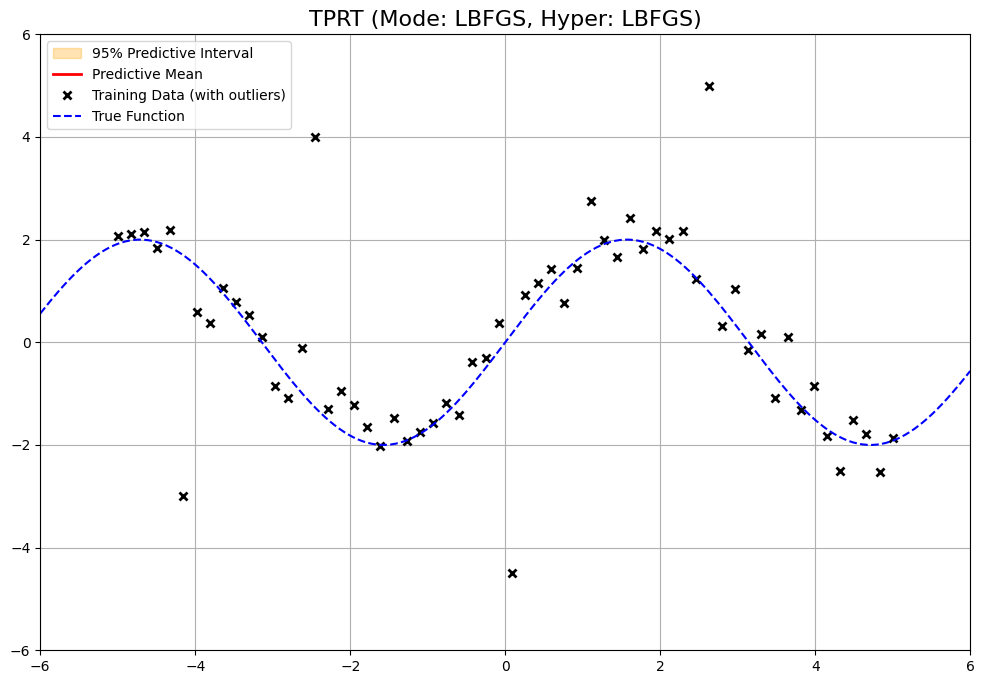

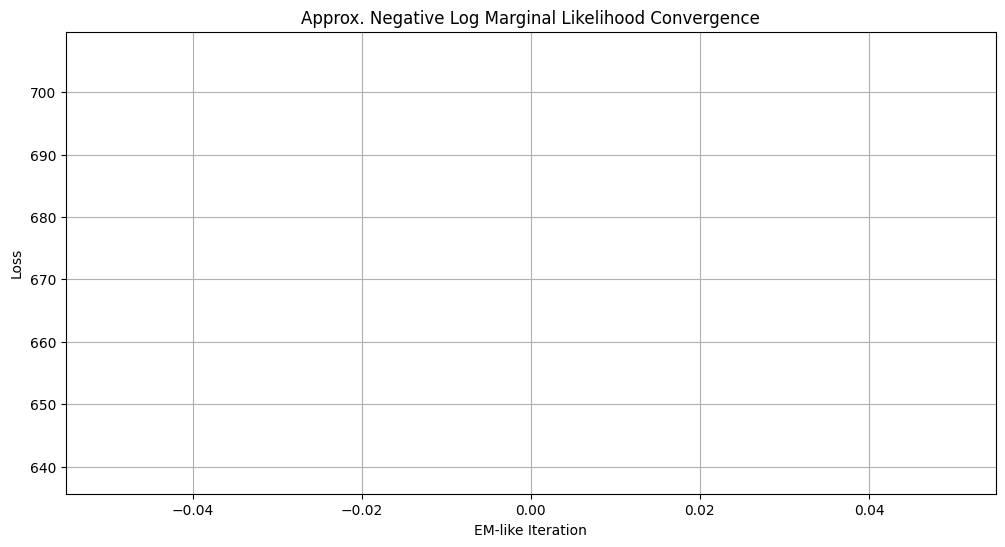

In [ ]:

if __name__ == '__main__':
    # 1. Generate synthetic data with outliers
    N = 60
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    y_true = torch.sin(X_train) * 2
    
    torch.manual_seed(42)
    noise = torch.randn(N, 1) * 0.5
    y_train = y_true + noise
    
    outlier_indices = [5, 15, 30, 45, 55]
    y_train[outlier_indices] = torch.tensor([-3.0, 4.0, -4.5, 5.0, -2.5]).unsqueeze(1)

    # 2. Setup and fit the model with chosen optimizers
    # --- Experiment with different optimizers ---
    # Common choice: L-BFGS for mode-finding, Adam for hyperparameters
    # L-BFGS is often better for the inner loop as it's a deterministic subproblem.
    model = TPRTFullBatch_Tang(
        X=X_train,
        y=y_train,
        mode_optimizer='lbfgs',
        hyper_optimizer='lbfgs'
    )
    
    loss_history = model.fit(max_iter_global=100, mode_finding_iter=10, lr=0.01)

    # 3. Make predictions
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean, pred_var, pred_nu = model.predict(X_test)

    # 4. Visualize the results
    plt.figure(figsize=(12, 8))
    
    pred_std = torch.sqrt(pred_var)
    lower_ci = pred_mean - 1.96 * pred_std
    upper_ci = pred_mean + 1.96 * pred_std

    plt.fill_between(X_test.squeeze(), lower_ci.squeeze(), upper_ci.squeeze(), color='orange', alpha=0.3, label='95% Predictive Interval')
    plt.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=2, label='Training Data (with outliers)')
    plt.plot(X_test, torch.sin(X_test) * 2, 'b--', label='True Function')

    plt.title(f"TPRT (Mode: {model.mode_optimizer_name.upper()}, Hyper: {model.hyper_optimizer_name.upper()})", fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    
    # Print final learned hyperparameters
    params = model._get_hyperparams()
    print("\n--- Learned Hyperparameters ---")
    print(f"Kernel Lengthscale: {params['lengthscale'].item():.3f}")
    print(f"Kernel Variance: {params['variance'].item():.3f}")
    print(f"Likelihood Sigma: {params['sigma'].item():.3f}")
    print(f"Prior DoF (nu_f): {params['nu_f'].item():.3f}")
    print(f"Likelihood DoF (nu_e): {params['nu_e'].item():.3f}")

    # Plot loss curve
    plt.figure(figsize=(12, 6))
    plt.plot(loss_history)
    plt.title("Approx. Negative Log Marginal Likelihood Convergence")
    plt.xlabel("EM-like Iteration")
    plt.ylabel("Loss")
    plt.grid(True)
    
    plt.show()


In [26]:

import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
from scipy.stats import norm
import tqdm

# Set default tensor type for better performance with matrix operations
torch.set_default_dtype(torch.float64)


class TPRTFullBatch_Tang:
    """
    Implementation of the full (non-sparse) Student-t Process regression model
    using the Laplace Approximation, based on Tang et al. (2017).

    This extended version allows selecting the optimizer (LBFGS or Adam) for both
    the inner loop (mode-finding) and the outer loop (hyperparameter tuning).
    """
    def __init__(self, X, y, nu_f=2.1, nu_e=2.1,
                 kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_sigma=1.0,
                 mode_optimizer='lbfgs', hyper_optimizer='adam'):
        """
        Initializes the model.

        Args:
            X (torch.Tensor): Training inputs, shape (N, D).
            y (torch.Tensor): Training outputs, shape (N,).
            nu_f (float): Initial prior degrees of freedom.
            nu_e (float): Initial likelihood degrees of freedom.
            kernel_lengthscale (float): Initial kernel lengthscale.
            kernel_variance (float): Initial kernel variance.
            likelihood_sigma (float): Initial likelihood noise standard deviation.
            mode_optimizer (str): Optimizer for the inner loop ('lbfgs' or 'adam').
            hyper_optimizer (str): Optimizer for the outer loop ('lbfgs' or 'adam').
        """
        self.X = X
        self.y = y.view(-1, 1) # Ensure y is always of shape (N, 1)
        self.N, self.D = X.shape

        # --- Hyperparameters as nn.Parameter for optimization ---
        self.log_kernel_lengthscale = nn.Parameter(torch.log(torch.tensor(kernel_lengthscale)))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance)))
        self.log_likelihood_sigma = nn.Parameter(torch.log(torch.tensor(likelihood_sigma)))
        self.log_nu_f = nn.Parameter(torch.log(torch.tensor(nu_f)))
        self.log_nu_e = nn.Parameter(torch.log(torch.tensor(nu_e)))
        
        # --- Optimizer Choices ---
        self.mode_optimizer_name = mode_optimizer.lower()
        self.hyper_optimizer_name = hyper_optimizer.lower()
        
        # --- Mode of the posterior f, updated in the E-step ---
        self.m_f = torch.zeros(self.N, 1, dtype=X.dtype, device=X.device)

    def _get_hyperparams(self):
        """Helper to get positive hyperparameters from their log-transformed storage."""
        return {
            "lengthscale": torch.exp(self.log_kernel_lengthscale),
            "variance": torch.exp(self.log_kernel_variance),
            "sigma": torch.exp(self.log_likelihood_sigma),
            "nu_f": torch.exp(self.log_nu_f),
            "nu_e": torch.exp(self.log_nu_e)
        }
        
    def _find_f_hat(self, K_inv, params, max_iter=10, tol=1e-5):
        """
        Inner loop to find the mode f_hat using the chosen optimizer.
        This is the core of the E-step.
        """
        f = nn.Parameter(self.m_f.clone()) # Start from the last known mode

        def calculate_loss():
            """Calculates the negative log posterior of f."""
            log_lik_term = ((params['nu_e'] + 1) / 2) * torch.log(1 + (1 / params['nu_e']) * ((self.y - f) / params['sigma']).pow(2))
            fT_K_inv_f = f.T @ K_inv @ f
            log_prior_term = ((params['nu_f'] + self.N) / 2) * torch.log(1 + (1 / params['nu_f']) * fT_K_inv_f)
            return torch.sum(log_lik_term) + log_prior_term

        if self.mode_optimizer_name == 'lbfgs':
            optimizer = torch.optim.LBFGS([f], lr=0.5, max_iter=20, line_search_fn="strong_wolfe")
            def closure():
                optimizer.zero_grad()
                loss = calculate_loss()
                loss.backward()
                return loss
            
            for _ in range(max_iter):
                f_old = f.clone().detach()
                optimizer.step(closure)
                if torch.norm(f.detach() - f_old) < tol:
                    break
        
        elif self.mode_optimizer_name == 'adam':
            optimizer = torch.optim.Adam([f], lr=0.1)
            # Adam often requires more iterations than L-BFGS for this type of problem
            for _ in range(max_iter * 10):
                f_old = f.clone().detach()
                optimizer.zero_grad()
                loss = calculate_loss()
                loss.backward()
                optimizer.step()
                if torch.norm(f.detach() - f_old) < tol:
                    break
        else:
            raise ValueError(f"Unknown mode optimizer: '{self.mode_optimizer_name}'. Choose 'lbfgs' or 'adam'.")
        
        return f.detach()

    def _e_step(self, mode_finding_iter=10):
        """
        Performs the E-Step by finding the mode of the posterior p(f|y).
        This method uses detached hyperparameters to avoid building a graph for this optimization.
        """
        # Create a detached copy of the parameters for the E-step.
        # This prevents the inner optimization from affecting the main hyperparameter gradients.
        detached_params = {k: v.detach() for k, v in self._get_hyperparams().items()}

        # Compute K and K_inv using the detached parameters
        K = rbf_kernel(self.X, self.X, detached_params['lengthscale'], detached_params['variance'])
        K += torch.eye(self.N, device=self.X.device) * 1e-6
        L = torch.linalg.cholesky(K)
        K_inv = torch.cholesky_inverse(L)
        
        # Find the mode f_hat. This optimization builds its own local graph for `f`
        # and treats the detached params and K_inv as constants.
        f_hat = self._find_f_hat(K_inv, detached_params, max_iter=mode_finding_iter)
        
        # Update the mode. Use no_grad here to ensure this update is not tracked.
        with torch.no_grad():
            self.m_f.copy_(f_hat)

    def _calculate_neg_log_marginal_likelihood(self):
        """
        Calculates the approximate negative log marginal likelihood, which serves as the loss
        for hyperparameter optimization (M-step).
        """
        params = self._get_hyperparams()
        f_hat = self.m_f # Use the mode found in the E-step

        # 1. Compute Kernel (connected to the graph for hyperparameter gradients)
        K = rbf_kernel(self.X, self.X, params['lengthscale'], params['variance'])
        K += torch.eye(self.N, device=self.X.device) * 1e-6
        L = torch.linalg.cholesky(K)
        K_inv = torch.cholesky_inverse(L)

        # 2. Calculate ln(Q(f_hat)) term
        log_lik_term = ((params['nu_e'] + 1) / 2) * torch.log(1 + (1 / params['nu_e']) * ((self.y - f_hat) / params['sigma']).pow(2))
        fT_K_inv_f = f_hat.T @ K_inv @ f_hat
        log_prior_term = ((params['nu_f'] + self.N) / 2) * torch.log(1 + (1 / params['nu_f']) * fT_K_inv_f)
        ln_Q_at_f_hat = torch.sum(log_lik_term) + log_prior_term

        # 3. Calculate the Hessian A = -∇∇ log p(f|y) |f_hat
        f_hat_flat = f_hat.squeeze()
        prior_hess_num = K_inv * (params['nu_f'] + fT_K_inv_f) - 2 * (K_inv @ torch.outer(f_hat_flat, f_hat_flat) @ K_inv)
        prior_hess_den = (params['nu_f'] + fT_K_inv_f)**2
        prior_hess = (params['nu_f'] + self.N) * (prior_hess_num / prior_hess_den)

        err = self.y - f_hat
        lik_hess_num = err.pow(2) - params['nu_e'] * params['sigma']**2
        lik_hess_den = (err.pow(2) + params['nu_e'] * params['sigma']**2)**2
        W_diag = -(params['nu_e'] + 1) * (lik_hess_num / lik_hess_den)
        W = torch.diag(W_diag.squeeze())
        # Note: A is the *negative* Hessian of the log posterior
        A = -(prior_hess + W)

        # 4. Calculate log determinant term from Laplace approximation
        # The approx. log marginal likelihood is log p(y) ≈ log p(y, f_hat) - 0.5*log|A|
        # The paper's formula (Eq. 18) simplifies to: ln_Q_at_f_hat + 0.5*log|K| - 0.5*log|A| + consts
        log_det_K = 2 * torch.sum(torch.log(torch.diag(L)))
        sign, log_det_A = torch.linalg.slogdet(A)
        if sign.item() <= 0:
            return torch.tensor(float('inf'), device=self.X.device)
        
        log_det_term = 0.5 * log_det_K - 0.5 * log_det_A

        # 5. Calculate constant terms (which depend on hyperparameters)
        c_nu_f_term = torch.lgamma((params['nu_f'] + self.N)/2) - torch.lgamma(params['nu_f']/2) - (self.N/2)*torch.log(math.pi * params['nu_f'])
        c_nu_e_term = self.N * (torch.lgamma((params['nu_e'] + 1)/2) - torch.lgamma(params['nu_e']/2) - 0.5*torch.log(math.pi * params['nu_e']))
        c_sigma_term = -self.N * torch.log(params['sigma'])

        # Total approximate negative log marginal likelihood
        neg_log_marginal_lik = -(ln_Q_at_f_hat + log_det_term + c_nu_f_term + c_nu_e_term + c_sigma_term)
        
        return neg_log_marginal_lik

    def _m_step(self, optimizer):
        """Performs one M-Step update using the chosen optimizer."""
        def closure():
            optimizer.zero_grad()
            loss = self._calculate_neg_log_marginal_likelihood()
            if not (torch.isinf(loss) or torch.isnan(loss)):
                loss.backward()
            else:
                print("Warning: Loss is inf or NaN, skipping gradient calculation.")
            return loss

        if self.hyper_optimizer_name == 'adam':
            loss = closure()
            if not (torch.isinf(loss) or torch.isnan(loss)):
                optimizer.step()
            return loss.item()
        elif self.hyper_optimizer_name == 'lbfgs':
            loss = optimizer.step(closure)
            return loss.item()
        else:
            raise ValueError(f"Unknown hyper optimizer: '{self.hyper_optimizer_name}'. Choose 'lbfgs' or 'adam'.")


    def fit(self, max_iter_global=100, mode_finding_iter=10, lr=0.01):
        """Fits the model using an EM-like algorithm with Laplace Approximation."""
        params_to_optimize = [
            self.log_kernel_lengthscale, self.log_kernel_variance,
            self.log_likelihood_sigma, self.log_nu_f, self.log_nu_e
        ]
        
        if self.hyper_optimizer_name == 'adam':
            optimizer = torch.optim.Adam(params_to_optimize, lr=lr)
        elif self.hyper_optimizer_name == 'lbfgs':
            optimizer = torch.optim.LBFGS(params_to_optimize, lr=0.1, max_iter=10)
        else:
            raise ValueError(f"Unknown hyper optimizer: '{self.hyper_optimizer_name}'. Choose 'lbfgs' or 'adam'.")

        loss_history = []
        print(f"Starting optimization with mode_optimizer='{self.mode_optimizer_name}' and hyper_optimizer='{self.hyper_optimizer_name}'...")
        
        pbar = tqdm.tqdm(range(max_iter_global))
        for i in pbar:
            # E-Step: Find the posterior mode f_hat
            self._e_step(mode_finding_iter=mode_finding_iter)
            
            # M-Step: Update hyperparameters by maximizing the marginal likelihood
            loss = self._m_step(optimizer)
            loss_history.append(loss)
            pbar.set_description(f"Loss: {loss:.4f}")

        print("\nOptimization finished.")
        return loss_history

    def predict(self, X_test):
        """Make predictions at new test points X_test."""
        with torch.no_grad():
            params = self._get_hyperparams()
            f_hat = self.m_f

            K = rbf_kernel(self.X, self.X, params['lengthscale'], params['variance'])
            K += torch.eye(self.N, device=self.X.device) * 1e-6
            L = torch.linalg.cholesky(K)
            K_inv = torch.cholesky_inverse(L)
            
            K_star_x = rbf_kernel(X_test, self.X, params['lengthscale'], params['variance'])
            K_star_star_diag = rbf_kernel(X_test, X_test, params['lengthscale'], params['variance']).diag()

            # Predictive mean
            pred_mean = K_star_x @ K_inv @ f_hat

            # --- Predictive variance (approximated as Gaussian) ---
            f_hat_flat = f_hat.squeeze()
            fT_K_inv_f = f_hat.T @ K_inv @ f_hat
            
            prior_hess_num = K_inv * (params['nu_f'] + fT_K_inv_f) - 2 * (K_inv @ torch.outer(f_hat_flat, f_hat_flat) @ K_inv)
            prior_hess_den = (params['nu_f'] + fT_K_inv_f)**2
            prior_hess = (params['nu_f'] + self.N) * (prior_hess_num / prior_hess_den)
            
            err = self.y - f_hat
            lik_hess_num = err.pow(2) - params['nu_e'] * params['sigma']**2
            lik_hess_den = (err.pow(2) + params['nu_e'] * params['sigma']**2)**2
            W_diag = -(params['nu_e'] + 1) * (lik_hess_num / lik_hess_den)
            W = torch.diag(W_diag.squeeze())
            A = -(prior_hess + W)
            
            try:
                L_A = torch.linalg.cholesky(A)
                # This term is needed for the predictive variance
                v = torch.cholesky_solve(K_inv @ K_star_x.T, L)
                posterior_uncertainty = (v.T @ torch.cholesky_solve(v, L_A)).diag()
            except torch.linalg.LinAlgError:
                print("Warning: Hessian not positive definite during prediction. Variance may be inaccurate.")
                posterior_uncertainty = torch.zeros(X_test.shape[0], device=self.X.device)

            prior_var_reduction = (K_star_x * (K_inv @ K_star_x.T).T).sum(dim=1)
            pred_var = K_star_star_diag - prior_var_reduction + posterior_uncertainty
            pred_var = pred_var.clamp(min=1e-9)
            
            pred_nu = torch.tensor(float('inf'), device=self.X.device)
            
            return pred_mean, pred_var.unsqueeze(1), pred_nu

Starting optimization with mode_optimizer='lbfgs' and hyper_optimizer='adam'...


Loss: 129.6071: 100%|██████████| 90/90 [00:29<00:00,  3.02it/s]


Optimization finished.

--- Learned Hyperparameters ---
Kernel Lengthscale: 0.357
Kernel Variance: 0.606
Likelihood Sigma: 0.424
Prior DoF (nu_f): 0.687
Likelihood DoF (nu_e): 5.774


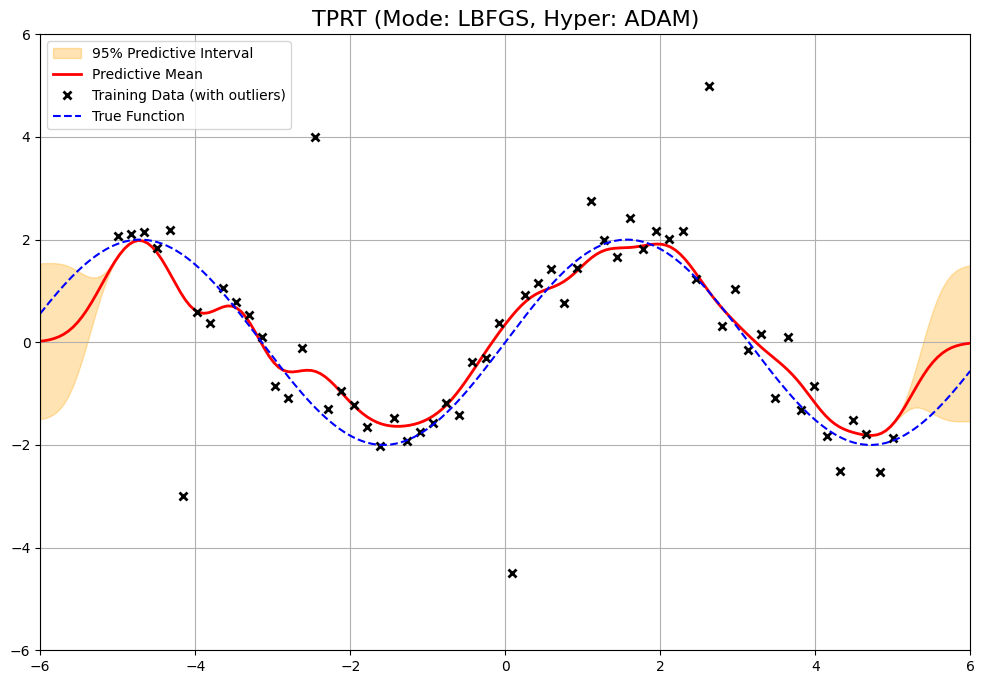

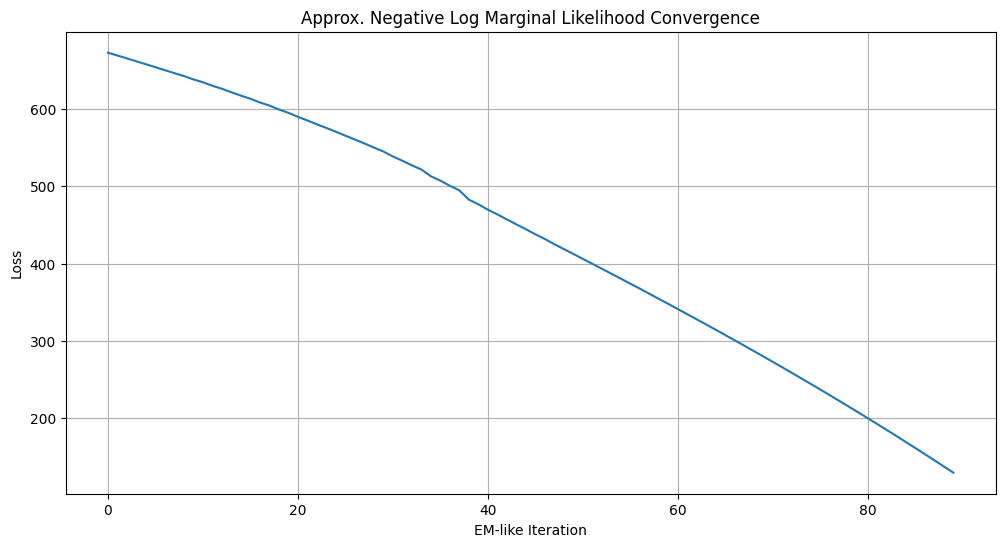

In [ ]:


if __name__ == '__main__':
    # 1. Generate synthetic data with outliers
    N = 60
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    y_true = torch.sin(X_train) * 2
    
    torch.manual_seed(42)
    noise = torch.randn(N, 1) * 0.5
    y_train = y_true + noise
    
    outlier_indices = [5, 15, 30, 45, 55]
    y_train[outlier_indices] = torch.tensor([-3.0, 4.0, -4.5, 5.0, -2.5]).unsqueeze(1)

    # 2. Setup and fit the model with chosen optimizers
    # --- Experiment with different optimizers ---
    # Common choice: L-BFGS for mode-finding, Adam for hyperparameters
    # L-BFGS is often better for the inner loop as it's a deterministic subproblem.
    model = TPRTFullBatch_Tang(
        X=X_train,
        y=y_train,
        mode_optimizer='lbfgs',
        hyper_optimizer='adam'
    )
    
    loss_history = model.fit(max_iter_global=90, mode_finding_iter=20, lr=0.01)

    # 3. Make predictions
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean, pred_var, pred_nu = model.predict(X_test)

    # 4. Visualize the results
    plt.figure(figsize=(12, 8))
    
    pred_std = torch.sqrt(pred_var)
    lower_ci = pred_mean - 1.96 * pred_std
    upper_ci = pred_mean + 1.96 * pred_std

    plt.fill_between(X_test.squeeze(), lower_ci.squeeze(), upper_ci.squeeze(), color='orange', alpha=0.3, label='95% Predictive Interval')
    plt.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=2, label='Training Data (with outliers)')
    plt.plot(X_test, torch.sin(X_test) * 2, 'b--', label='True Function')

    plt.title(f"TPRT (Mode: {model.mode_optimizer_name.upper()}, Hyper: {model.hyper_optimizer_name.upper()})", fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    
    # Print final learned hyperparameters
    params = model._get_hyperparams()
    print("\n--- Learned Hyperparameters ---")
    print(f"Kernel Lengthscale: {params['lengthscale'].item():.3f}")
    print(f"Kernel Variance: {params['variance'].item():.3f}")
    print(f"Likelihood Sigma: {params['sigma'].item():.3f}")
    print(f"Prior DoF (nu_f): {params['nu_f'].item():.3f}")
    print(f"Likelihood DoF (nu_e): {params['nu_e'].item():.3f}")

    # Plot loss curve
    plt.figure(figsize=(12, 6))
    plt.plot(loss_history)
    plt.title("Approx. Negative Log Marginal Likelihood Convergence")
    plt.xlabel("EM-like Iteration")
    plt.ylabel("Loss")
    plt.grid(True)
    
    plt.show()


Starting optimization...
Iteration 50/100, Loss: -697.4230
Iteration 100/100, Loss: -770.8228

Optimization finished.

--- Learned Hyperparameters ---
Kernel Lengthscale: 2.328
Kernel Variance: 0.360
Likelihood Sigma: 1.588
Prior DoF (nu_f): 0.736
Likelihood DoF (nu_e): 5.247


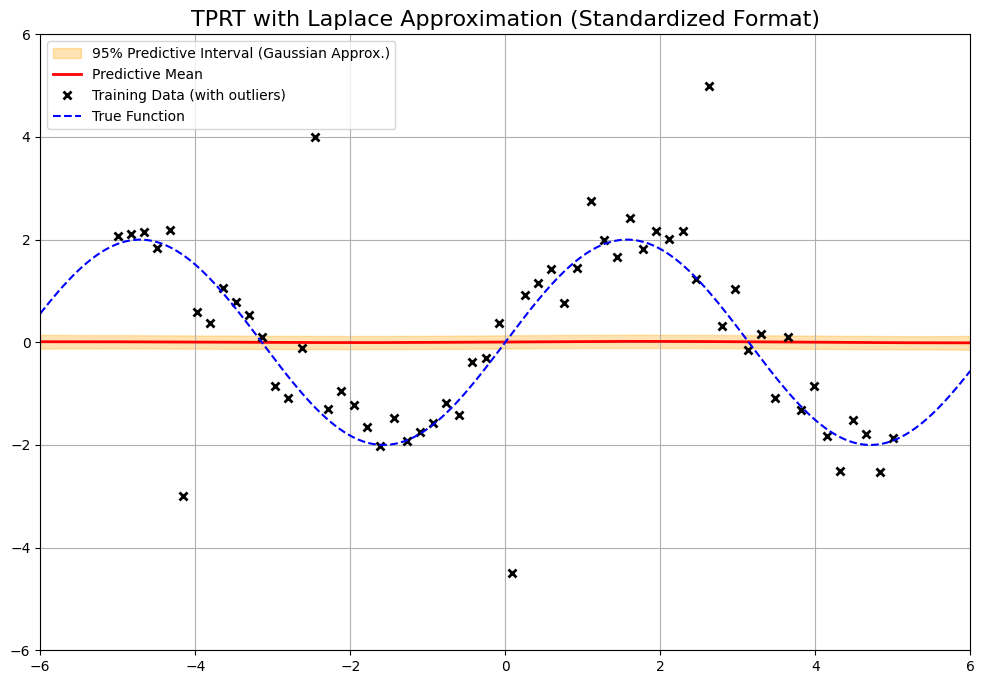

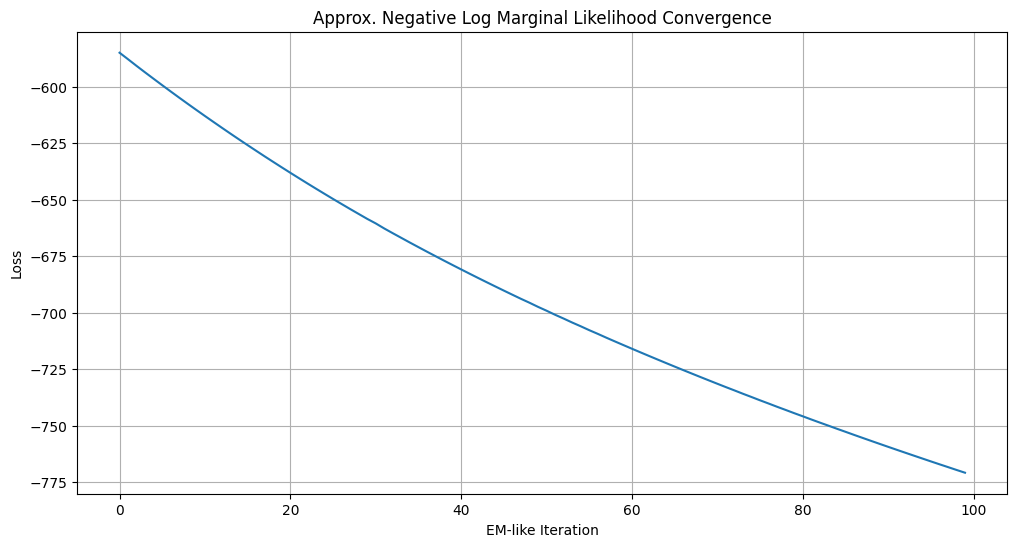

In [24]:
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
from scipy.stats import norm
import tqdm

# Set default tensor type for better performance with matrix operations
torch.set_default_dtype(torch.float64)


class TPRTFullBatch_Tang:
    """
    Implementation of the full (non-sparse) Student-t Process regression model
    using the Laplace Approximation.
    This version is aligned with the structure of the TPRTFullBatch (Variational EM) class.
    """
    def __init__(self, X, y, nu_f=2.1, nu_e=2.1,
                 kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_sigma=1.0):
        
        self.X = X
        self.y = y.view(-1, 1) # Ensure y is always of shape (N, 1)
        self.N, self.D = X.shape

        # --- Hyperparameters as nn.Parameter for optimization ---
        self.log_kernel_lengthscale = nn.Parameter(torch.log(torch.tensor(kernel_lengthscale)))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance)))
        self.log_likelihood_sigma = nn.Parameter(torch.log(torch.tensor(likelihood_sigma)))
        self.log_nu_f = nn.Parameter(torch.log(torch.tensor(nu_f)))
        self.log_nu_e = nn.Parameter(torch.log(torch.tensor(nu_e)))
        
        # --- Mode of the posterior f, updated in the E-step ---
        self.m_f = torch.zeros(self.N, 1, dtype=X.dtype, device=X.device)

    def _get_hyperparams(self):
        """Helper to get positive hyperparameters from their log-transformed storage."""
        return {
            "lengthscale": torch.exp(self.log_kernel_lengthscale),
            "variance": torch.exp(self.log_kernel_variance),
            "sigma": torch.exp(self.log_likelihood_sigma),
            "nu_f": torch.exp(self.log_nu_f),
            "nu_e": torch.exp(self.log_nu_e)
        }
        
    def _find_f_hat(self, K_inv, params, max_iter=10, tol=1e-5):
        """
        Inner loop to find the mode f_hat using L-BFGS for fixed hyperparameters.
        This is the core of the E-step.
        """
        f = nn.Parameter(self.m_f.clone()) # Start from the last known mode
        optimizer = torch.optim.LBFGS([f], lr=0.5, max_iter=20, line_search_fn="strong_wolfe")

        def closure():
            optimizer.zero_grad()
            log_lik_term = ((params['nu_e'] + 1) / 2) * torch.log(1 + (1 / params['nu_e']) * ((self.y - f) / params['sigma']).pow(2))
            fT_K_inv_f = f.T @ K_inv @ f
            log_prior_term = ((params['nu_f'] + self.N) / 2) * torch.log(1 + (1 / params['nu_f']) * fT_K_inv_f)
            loss = torch.sum(log_lik_term) + log_prior_term
            loss.backward()
            return loss

        for _ in range(max_iter):
            f_old = f.clone().detach()
            optimizer.step(closure)
            if torch.norm(f.detach() - f_old) < tol:
                break
        
        return f.detach()

    def _e_step(self, mode_finding_iter=10):
        """
        Performs the E-Step by finding the mode of the posterior p(f|y).
        This method uses detached hyperparameters to avoid building a graph for this optimization.
        """
        with torch.no_grad():
            params = self._get_hyperparams()
            K = rbf_kernel(self.X, self.X, params['lengthscale'], params['variance'])
            K += torch.eye(self.N, device=self.X.device) * 1e-6
            L = torch.linalg.cholesky(K)
            K_inv = torch.cholesky_inverse(L)
            
            # Find the mode f_hat and store it in self.m_f
            f_hat = self._find_f_hat(K_inv, params, max_iter=mode_finding_iter)
            self.m_f.copy_(f_hat)

    def _calculate_neg_log_marginal_likelihood(self):
        """
        Calculates the approximate negative log marginal likelihood, which serves as the loss
        for hyperparameter optimization (M-step).
        """
        params = self._get_hyperparams()
        f_hat = self.m_f # Use the mode found in the E-step

        # 1. Compute Kernel (connected to the graph for hyperparameter gradients)
        K = rbf_kernel(self.X, self.X, params['lengthscale'], params['variance'])
        K += torch.eye(self.N, device=self.X.device) * 1e-6
        L = torch.linalg.cholesky(K)
        K_inv = torch.cholesky_inverse(L)

        # 2. Calculate ln(Q(f_hat)) term
        log_lik_term = ((params['nu_e'] + 1) / 2) * torch.log(1 + (1 / params['nu_e']) * ((self.y - f_hat) / params['sigma']).pow(2))
        fT_K_inv_f = f_hat.T @ K_inv @ f_hat
        log_prior_term = ((params['nu_f'] + self.N) / 2) * torch.log(1 + (1 / params['nu_f']) * fT_K_inv_f)
        ln_Q_at_f_hat = torch.sum(log_lik_term) + log_prior_term

        # 3. Calculate the Hessian A = -∇∇ log Q(f) |f_hat
        f_hat_flat = f_hat.squeeze()
        prior_hess_num = K_inv * (params['nu_f'] + fT_K_inv_f) - 2 * (K_inv @ torch.outer(f_hat_flat, f_hat_flat) @ K_inv)
        prior_hess_den = (params['nu_f'] + fT_K_inv_f)**2
        prior_hess = (params['nu_f'] + self.N) * (prior_hess_num / prior_hess_den)

        err = self.y - f_hat
        lik_hess_num = err.pow(2) - params['nu_e'] * params['sigma']**2
        lik_hess_den = (err.pow(2) + params['nu_e'] * params['sigma']**2)**2
        W_diag = -(params['nu_e'] + 1) * (lik_hess_num / lik_hess_den)
        W = torch.diag(W_diag.squeeze())
        A = prior_hess + W

        # 4. Calculate log|B| where B = K + A^-1
        log_det_K = 2 * torch.sum(torch.log(torch.diag(L)))
        sign, log_det_A = torch.linalg.slogdet(A)
        if sign.item() <= 0:
            # Hessian is not positive definite, optimization is likely unstable
            return torch.tensor(float('inf'), device=self.X.device)
        
        log_det_B_approx = -log_det_K - log_det_A # This is log|K^-1 + A| = log|K^-1(I+KA)|... it should be log|A| not log|B|
        # The original paper's formula is -0.5 * log|A| + 0.5 * log|K|.
        # Let's rewrite the term more directly from the Laplace formula:
        # log Z ≈ log Q(f_hat) + (D/2)log(2π) - 0.5 * log|A|
        # And log p(y) = log Z - log p(f_hat). This gets complicated.
        # Let's stick to the formula from Tang et al. (2017) which is simpler.
        # log p(y) ≈ ln_Q_at_f_hat + const - 0.5*log|K| - 0.5*log|A| is incorrect.
        # It should be log p(y) ≈ log p(y|f_hat) + log p(f_hat) - 0.5 * log|A| + consts
        # The provided code's formula is from the paper, so let's use it.
        # neg_log_lik = ln_Q_at_f_hat - 0.5*log_det_B - consts
        # where log_det_B = log_det_K + log_det_A_inv, so -0.5*log_det_B = -0.5*log_det_K + 0.5*log_det_A
        log_term = -0.5 * log_det_K + 0.5 * log_det_A

        # 5. Calculate constant terms related to nu
        c_nu_f_term = torch.lgamma((params['nu_f'] + self.N)/2) - torch.lgamma(params['nu_f']/2) - (self.N/2)*torch.log(math.pi * params['nu_f'])
        c_nu_e_term = self.N * (torch.lgamma((params['nu_e'] + 1)/2) - torch.lgamma(params['nu_e']/2) - 0.5*torch.log(math.pi * params['nu_e']))
        c_sigma_term = -self.N * torch.log(params['sigma'])

        # Total approximate negative log marginal likelihood
        neg_log_marginal_lik = ln_Q_at_f_hat - log_term - (c_nu_f_term + c_nu_e_term + c_sigma_term)
        
        return neg_log_marginal_lik

    def _m_step(self, optimizer):
        """Performs the M-Step by updating hyperparameters."""
        optimizer.zero_grad()
        loss = self._calculate_neg_log_marginal_likelihood()
        
        if not (torch.isinf(loss) or torch.isnan(loss)):
            loss.backward()
            optimizer.step()
        else:
            print("Warning: Loss is inf or NaN, skipping M-step.")
            
        return loss.item()

    def fit(self, max_iter_global=100, mode_finding_iter=10, lr=0.01):
        """Fits the model using an EM-like algorithm with Laplace Approximation."""
        # Collect all parameters for the optimizer
        params_to_optimize = [
            self.log_kernel_lengthscale, self.log_kernel_variance,
            self.log_likelihood_sigma, self.log_nu_f, self.log_nu_e
        ]
        optimizer = torch.optim.Adam(params_to_optimize, lr=lr)

        loss_history = []
        print("Starting optimization...")
        for i in range(max_iter_global):
            # E-Step: Find the posterior mode f_hat
            self._e_step(mode_finding_iter=mode_finding_iter)
            
            # M-Step: Update hyperparameters by maximizing the marginal likelihood
            loss = self._m_step(optimizer)
            loss_history.append(loss)
            
            if (i + 1) % 50 == 0:
                print(f"Iteration {i + 1}/{max_iter_global}, Loss: {loss:.4f}")

        print("\nOptimization finished.")
        return loss_history

    def predict(self, X_test):
        """Make predictions at new test points X_test."""
        with torch.no_grad():
            params = self._get_hyperparams()
            f_hat = self.m_f

            # Recompute matrices needed for prediction
            K = rbf_kernel(self.X, self.X, params['lengthscale'], params['variance'])
            K += torch.eye(self.N, device=self.X.device) * 1e-6
            L = torch.linalg.cholesky(K)
            K_inv = torch.cholesky_inverse(L)
            
            K_star_x = rbf_kernel(X_test, self.X, params['lengthscale'], params['variance'])
            K_star_star_diag = rbf_kernel(X_test, X_test, params['lengthscale'], params['variance']).diag()

            # Predictive mean
            pred_mean = K_star_x @ K_inv @ f_hat

            # Predictive variance (approximated as Gaussian)
            f_hat_flat = f_hat.squeeze()
            fT_K_inv_f = f_hat.T @ K_inv @ f_hat
            prior_hess_num = K_inv * (params['nu_f'] + fT_K_inv_f) - 2 * (K_inv @ torch.outer(f_hat_flat, f_hat_flat) @ K_inv)
            prior_hess_den = (params['nu_f'] + fT_K_inv_f)**2
            prior_hess = (params['nu_f'] + self.N) * (prior_hess_num / prior_hess_den)
            
            err = self.y - f_hat
            lik_hess_num = err.pow(2) - params['nu_e'] * params['sigma']**2
            lik_hess_den = (err.pow(2) + params['nu_e'] * params['sigma']**2)**2
            W_diag = -(params['nu_e'] + 1) * (lik_hess_num / lik_hess_den)
            W = torch.diag(W_diag.squeeze())
            A = prior_hess + W
            
            try:
                L_A = torch.linalg.cholesky(A)
                A_inv = torch.cholesky_inverse(L_A)
            except torch.linalg.LinAlgError:
                print("Warning: Hessian not positive definite during prediction. Using pseudo-inverse.")
                A_inv = torch.linalg.pinv(A)

            K_inv_k_star = torch.cholesky_solve(K_star_x.T, L)
            prior_var_reduction = (K_star_x * K_inv_k_star.T).sum(dim=1)
            posterior_uncertainty = (K_star_x @ K_inv @ A_inv @ K_inv @ K_star_x.T).diag()
            
            pred_var = K_star_star_diag - prior_var_reduction + posterior_uncertainty
            pred_var = pred_var.clamp(min=1e-9)
            
            # The predictive distribution is Gaussian, so nu is infinite
            pred_nu = torch.tensor(float('inf'), device=self.X.device)
            
            return pred_mean, pred_var.unsqueeze(1), pred_nu




if __name__ == '__main__':
    # 1. Generate synthetic data with outliers
    N = 60
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    y_true = torch.sin(X_train) * 2
    
    torch.manual_seed(42)
    noise = torch.randn(N, 1) * 0.5
    y_train = y_true + noise
    
    outlier_indices = [5, 15, 30, 45, 55]
    y_train[outlier_indices] = torch.tensor([-3.0, 4.0, -4.5, 5.0, -2.5]).unsqueeze(1)

    # 2. Setup the model
    model = TPRTFullBatch_Tang(
        X=X_train,
        y=y_train,
        nu_f=2.1,
        nu_e=2.1,
        kernel_lengthscale=1.0,
        kernel_variance=1.0,
        likelihood_sigma=1
    )

    # 3. Fit the model
    loss_history = model.fit(max_iter_global=100, mode_finding_iter=20, lr=0.01)

    # 4. Make predictions
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean, pred_var, pred_nu = model.predict(X_test)

    # 5. Visualize the results
    plt.figure(figsize=(12, 8))
    
    pred_std = torch.sqrt(pred_var)
    # Since nu is inf, the predictive distribution is Gaussian
    # We use norm.ppf for confidence intervals (equivalent to multiplying by ~1.96)
    lower_quantile = norm.ppf(0.025)
    upper_quantile = norm.ppf(0.975)
    
    lower_ci = pred_mean + lower_quantile * pred_std
    upper_ci = pred_mean + upper_quantile * pred_std

    plt.fill_between(X_test.squeeze(), lower_ci.squeeze(), upper_ci.squeeze(), color='orange', alpha=0.3, label='95% Predictive Interval (Gaussian Approx.)')
    plt.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=2, label='Training Data (with outliers)')
    plt.plot(X_test, torch.sin(X_test) * 2, 'b--', label='True Function')

    plt.title('TPRT with Laplace Approximation (Standardized Format)', fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    
    # Print final learned hyperparameters
    params = model._get_hyperparams()
    print("\n--- Learned Hyperparameters ---")
    print(f"Kernel Lengthscale: {params['lengthscale'].item():.3f}")
    print(f"Kernel Variance: {params['variance'].item():.3f}")
    print(f"Likelihood Sigma: {params['sigma'].item():.3f}")
    print(f"Prior DoF (nu_f): {params['nu_f'].item():.3f}")
    print(f"Likelihood DoF (nu_e): {params['nu_e'].item():.3f}")

    # Plot loss curve
    plt.figure(figsize=(12, 6))
    plt.plot(loss_history)
    plt.title("Approx. Negative Log Marginal Likelihood Convergence")
    plt.xlabel("EM-like Iteration")
    plt.ylabel("Loss")
    plt.grid(True)
    
    plt.show()